In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals

import warnings

warnings.simplefilter("ignore")

# general purpose packages
import pandas as pd
import numpy as np
import os
import json
import time
import re
import csv
import subprocess
import sys

from dotenv import load_dotenv
from pathlib import Path

import scipy.stats as stats
import statsmodels.stats as smstats
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import sklearn

import umap

from multiprocessing import Process, Manager, Pool
import multiprocessing
from functools import partial

from collections import Counter

import seaborn as sns

sns.set()

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

matplotlib.rcParams["backend"] = "Qt5Agg"
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter

from IPython.display import display, Image

from adjustText import adjust_text
import builtins

%matplotlib inline

# for working with sam/bam files
import HTSeq

# for working with fasta files for example
from Bio import SeqIO

# for working with yaml files
import ruamel.yaml

import itertools

In [2]:
def get_pvalue_star(pval, thr=0.05):
    if thr == 0.05:
        if pval < 0.001:
            return "***"
        elif pval < 0.01:
            return "**"
        elif pval < 0.05:
            return "*"
        else:
            return "ns"
    elif thr == 0.1:
        if pval < 0.001:
            return "***"
        elif pval < 0.01:
            return "**"
        elif pval < 0.1:
            return "*"
        else:
            return "ns"

In [3]:
# 1. Load the environment variables
load_dotenv("CRISPR_projects.scicore.env")

# 2. Reconstruct the subdirs dictionary
subdirs = {
    "lab_group_dir": os.getenv("LAB_GROUP_DIR"),
    "main_project_dir": os.getenv("MAIN_PROJECT_DIR"),
    "wf_dir": os.getenv("WF_DIR"),
    "UCSCtracks_dir": os.getenv("UCSC_TRACKS_DIR"),
    "UCSCtracks_trackfiles_dir": os.getenv("UCSC_TRACKFILES_DIR"),
    "UCSCtracks_trackhubs_dir": os.getenv("UCSC_TRACKHUBS_DIR"),
    "human_annotation_dir": os.getenv("HUMAN_ANNOTATION_DIR"),
    "shared_project_dir": os.getenv("SHARED_PROJECT_DIR"),
    "temp_dir": os.getenv("TEMP_DIR"),
    "slurm_dir": os.getenv("SLURM_DIR"),
    "slurm_scripts_dir": os.getenv("SLURM_SCRIPTS_DIR"),
    "figures_dir": os.getenv("FIGURES_DIR"),
    "tables_dir": os.getenv("TABLES_DIR"),
    "fastq_dir": os.getenv("FASTQ_DIR"),
    "metadata_dir": os.getenv("METADATA_DIR"),
    "wf_runs_dir": os.getenv("WF_RUNS_DIR"),
}

# 3. Reconstruct the file_paths dictionary
file_paths = {
    "human_genome_file": os.getenv("HUMAN_GENOME_FILE"),
    "human_chrom_sizes_file": os.getenv("HUMAN_CHROM_SIZES_FILE"),
    "human_annotation_file": os.getenv("HUMAN_ANNOTATION_FILE"),
    "human_basic_annotation_file": os.getenv("HUMAN_BASIC_ANNOTATION_FILE"),
    "human_RNAcentral_annotation_file": os.getenv("HUMAN_RNACENTRAL_ANNOTATION_FILE"),
    "human_enriched_annotation_file": os.getenv("HUMAN_ENRICHED_ANNOTATION_FILE"),
    "human_RefSeq_annotation_file": os.getenv("HUMAN_REFSEQ_ANNOTATION_FILE"),
    "human_RefSeq_chrNames": os.getenv("HUMAN_REFSEQ_CHRNAMES"),
    "human_PRErRNA_file": os.getenv("HUMAN_PRERRNA_FILE"),
    "human_polyAsite_atlas": os.getenv("HUMAN_POLYASITE_ATLAS"),
    "human_tandem_PAS": os.getenv("HUMAN_TANDEM_PAS"),
}

# 4. Safely create all subdirectories
# Using os.makedirs is highly preferred over os.system('mkdir -p')
# because it avoids opening a subshell and handles permissions gracefully in pure Python.
for path in subdirs.values():
    if path:  # Safety check to ensure the variable was actually found in the .env
        os.makedirs(path, exist_ok=True)

print("Environment loaded and directories verified.")

Environment loaded and directories verified.


# lincRNA translation in liver

## transfer TCGA data from protected environment

In [6]:
out = subprocess.check_output(
    "mkdir -p " + subdirs["UCSCtracks_dir"] + "TCGA_LIHC/", shell=True
)
out = subprocess.check_output(
    "mkdir -p " + subdirs["UCSCtracks_dir"] + "TCGA_LIHC/metadata/", shell=True
)
out = subprocess.check_output(
    "mkdir -p " + subdirs["wf_runs_dir"] + "TCGA_LIHC", shell=True
)
out = subprocess.check_output(
    "mkdir -p " + subdirs["wf_runs_dir"] + "TCGA_LIHC/tables/", shell=True
)
out = subprocess.check_output(
    "mkdir -p " + subdirs["wf_runs_dir"] + "TCGA_LIHC/annotation/", shell=True
)

run the script 'transfer_data_from_sciCOREplus.sh' in ``subdirs['wf_runs_dir']``

## prepare liver cell line data

In [ ]:
# take from Scientific Data publication: PMID: 40885748

In [16]:
c = """SRR30526535
SRR30526546
SRR30526606
SRR30526612
SRR30526633
SRR30526634"""

command = (
    "mkdir -p "
    + subdirs["fastq_dir"]
    + "SRA/ && cd "
    + subdirs["fastq_dir"]
    + "SRA/; \n"
)
# prefetch needs to be run from login node
command = command + "prefetch " + " ".join(c.split("\n")) + "\n"

# fasterq and pigz should be run from computational node, with pigz installed e.g. via conda
for elem in c.split("\n"):
    command = command + "fasterq-dump -p -e 14 " + elem + "; "

command = command + "\n"

for elem in c.split("\n"):
    command = (
        command + "pigz -p 14 " + elem + "_1.fastq; pigz -p 14 " + elem + "_2.fastq; "
    )
print(command)
# Run the printed commands in bash from the login nodes WITH Web Access (prefetch) and computational nodes (fasterq-dump and pigz don't need web access)

mkdir -p /scicore/home/zavolan/GROUP/CRISPR_projects/input_fastq/SRA/ && cd /scicore/home/zavolan/GROUP/CRISPR_projects/input_fastq/SRA/; 
prefetch SRR30526535 SRR30526546 SRR30526606 SRR30526612 SRR30526633 SRR30526634
fasterq-dump -p -e 14 SRR30526535; fasterq-dump -p -e 14 SRR30526546; fasterq-dump -p -e 14 SRR30526606; fasterq-dump -p -e 14 SRR30526612; fasterq-dump -p -e 14 SRR30526633; fasterq-dump -p -e 14 SRR30526634; 
pigz -p 14 SRR30526535_1.fastq; pigz -p 14 SRR30526535_2.fastq; pigz -p 14 SRR30526546_1.fastq; pigz -p 14 SRR30526546_2.fastq; pigz -p 14 SRR30526606_1.fastq; pigz -p 14 SRR30526606_2.fastq; pigz -p 14 SRR30526612_1.fastq; pigz -p 14 SRR30526612_2.fastq; pigz -p 14 SRR30526633_1.fastq; pigz -p 14 SRR30526633_2.fastq; pigz -p 14 SRR30526634_1.fastq; pigz -p 14 SRR30526634_2.fastq; 


In [69]:
# remove .sra files after successful processing
command = ""
for elem in c.split("\n"):
    command = command + "rm -f -r " + subdirs["fastq_dir"] + "SRA/" + elem + "/; "
print(command)

rm -f -r /scicore/home/zavolan/GROUP/CRISPR_projects/input_fastq/SRA/SRR30526535/; rm -f -r /scicore/home/zavolan/GROUP/CRISPR_projects/input_fastq/SRA/SRR30526546/; rm -f -r /scicore/home/zavolan/GROUP/CRISPR_projects/input_fastq/SRA/SRR30526606/; rm -f -r /scicore/home/zavolan/GROUP/CRISPR_projects/input_fastq/SRA/SRR30526612/; rm -f -r /scicore/home/zavolan/GROUP/CRISPR_projects/input_fastq/SRA/SRR30526633/; rm -f -r /scicore/home/zavolan/GROUP/CRISPR_projects/input_fastq/SRA/SRR30526634/; 


In [72]:
os.system(
    """find """
    + subdirs["fastq_dir"]
    + "SRA/"
    + """ -name '*.fastq.gz' > """
    + subdirs["temp_dir"]
    + """SRA_fastq_files.tsv"""
)
SRA_fastq_files = pd.read_csv(
    subdirs["temp_dir"] + "SRA_fastq_files.tsv",
    delimiter="\t",
    index_col=None,
    header=None,
)
SRA_fastq_files.columns = ["path"]
SRA_fastq_files["sample"] = SRA_fastq_files.apply(
    lambda x: x["path"].split("/")[-1].split("_")[0], 1
)
SRA_fastq_files["pair"] = SRA_fastq_files.apply(
    lambda x: x["path"].split("/")[-1].split("_")[1].split(".fastq")[0], 1
)
SRA_fastq_files = pd.merge(
    SRA_fastq_files.loc[SRA_fastq_files["pair"] == "1"][["sample", "path"]].rename(
        columns={"path": "fq1"}
    ),
    SRA_fastq_files.loc[SRA_fastq_files["pair"] == "2"][["sample", "path"]].rename(
        columns={"path": "fq2"}
    ),
    how="inner",
    on="sample",
)

SRA_fastq_files["source"] = "CLUSTER"
SRA_fastq_files = SRA_fastq_files[["sample", "source", "fq1", "fq2"]]
SRA_fastq_files.to_csv(
    subdirs["metadata_dir"] + "start_samples.rnaseq.pe.tsv",
    sep=str("\t"),
    header=True,
    index=None,
    quoting=csv.QUOTE_NONE,
)

## Prepare .yaml config file and run WF

### create "snakemake" conda env

In [13]:
# install conda env with snakemake (also installs python and pandas)
command = "conda create -c conda-forge -c bioconda -n snakemake snakemake"
command

'conda create -c conda-forge -c bioconda -n snakemake snakemake'

In [14]:
# run snakemake under created conda environment snakemake:
# conda activate snakemake

In [15]:
# install slurm executor
# pip install snakemake-executor-plugin-slurm

### for PE - human

In [7]:
organism = "human"

gtf_chrs = pd.read_csv(
    file_paths[organism + "_basic_annotation_file"],
    delimiter="\t",
    index_col=None,
    header=None,
    usecols=[0],
    skiprows=5,
)
chromosome_list = list(gtf_chrs[0].unique())

In [12]:
# load default rule_config, modify it and save
WF_version = "Asiers_HepG2_Huh7_RNAseq_v1"

yaml = ruamel.yaml.YAML()
yaml.preserve_quotes = True
with open(subdirs["wf_dir"] + "config.template.yaml") as f_read:
    data = yaml.load(f_read)
data["samples_file"] = subdirs["metadata_dir"] + "start_samples.rnaseq.pe.tsv"

data["output_dir"] = subdirs["wf_runs_dir"] + WF_version + "/output/"
data["local_log"] = subdirs["wf_runs_dir"] + WF_version + "/output/local_log/"
data["cluster_log"] = subdirs["wf_runs_dir"] + WF_version + "/output/cluster_log/"

data["organism"] = organism
data["genome_file"] = file_paths[organism + "_genome_file"]
data["chrom_sizes"] = file_paths[organism + "_chrom_sizes_file"]
data["gtf_file"] = file_paths[organism + "_basic_annotation_file"]

# this is the same file that was used to quantify TCGA-LIHC data on Scicore+
data["exonic_segments_gtf"] = (
    subdirs["wf_runs_dir"]
    + "TCGA_LIHC/annotation/Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.gtf"
)
# data['exonic_segments_bed'] = file_paths[organism+'_exonic_segments_bed']
# data['gene_type_segments_gtf'] = file_paths[organism+'_gene_type_segments_gtf']

data["chromosomes"] = " ".join(chromosome_list)
data["tandem_pas"] = file_paths[organism + "_tandem_PAS"]

data["PAQ_min_distance_start_to_proximal"] = "1"
data["PAQ_coverage_unstranded"] = "yes"

data["PAQ_min_length_mean_coverage"] = "50"
data["PAQ_min_mean_exon_coverage"] = "1"

data["PAQ_coverage_downstream_extension"] = "100"
data["PAQ_distal_downstream_extension"] = "50"

data["PAQ_max_mean_coverage"] = "50"
data["PAQ_cluster_distance"] = "1"
data["PAQ_upstream_cluster_extension"] = "50"

data["PAQ_coverage_mse_ratio_limit"] = "0.5"

data["PAQ_fragment_length"] = "1"

for dir_path in [data["output_dir"], data["local_log"], data["cluster_log"]]:
    command = "mkdir -p " + dir_path
    out = subprocess.check_output(command, shell=True)

with open(
    subdirs["wf_runs_dir"]
    + WF_version
    + "/config_"
    + "_and_".join(chromosome_list)
    + ".yaml",
    "w",
) as f_write:
    yaml.dump(data, f_write)

# WF_step = "prepare-faster"
WF_step = "quantification-faster"
# WF_step = "PAQR-quantify"

command = (
    """snakemake \
--snakefile """
    + subdirs["wf_dir"]
    + """Snakefile-"""
    + WF_step
    + """ \
--scheduler greedy \
--configfile """
    + subdirs["wf_runs_dir"]
    + WF_version
    + "/config_"
    + "_and_".join(chromosome_list)
    + ".yaml"
    + """ \
--printshellcmds \
--software-deployment-method conda apptainer \
--conda-frontend conda \
--apptainer-args "--bind """
    + subdirs["wf_dir"]
    + ","
    + subdirs["lab_group_dir"]
    + """" \
--executor slurm \
--profile """
    + subdirs["wf_dir"]
    + "profile"
    + """ \
--nolock \
-np"""
)

print(command)
# run the printed command on the login node with activated "snakemake" environment (see above)

snakemake --snakefile /scicore/home/zavolan/mirono0000/Projects/CRISPR_projects/WF/Snakefile-quantification-faster --scheduler greedy --configfile /scicore/home/zavolan/GROUP/CRISPR_projects/wf_runs/Asiers_HepG2_Huh7_RNAseq_v1/config_chr1_and_chr2_and_chr3_and_chr4_and_chr5_and_chr6_and_chr7_and_chr8_and_chr9_and_chr10_and_chr11_and_chr12_and_chr13_and_chr14_and_chr15_and_chr16_and_chr17_and_chr18_and_chr19_and_chr20_and_chr21_and_chr22_and_chrX_and_chrY_and_chrM.yaml --printshellcmds --software-deployment-method conda apptainer --conda-frontend conda --apptainer-args "--bind /scicore/home/zavolan/mirono0000/Projects/CRISPR_projects/WF/,/scicore/home/zavolan/GROUP/" --executor slurm --profile /scicore/home/zavolan/mirono0000/Projects/CRISPR_projects/WF/profile --nolock -np


## Aggregate and library-size-normalize coverage from bigwig files, for visualization in UCSC

### Load and combine gene counts obtained on standard Scicore

In [107]:
organism = "human"
WF_version = "Asiers_HepG2_Huh7_RNAseq_v1"

out = subprocess.check_output(
    """find """
    + subdirs["wf_runs_dir"]
    + WF_version
    + "/output/gene_expression_quantification/"
    + organism
    + "/FeatureCounts_exonic_segments/"
    + """ -name '*.exonic_segments.txt' > """
    + subdirs["temp_dir"]
    + """exonic_segments_FeatureCounts.files.txt""",
    shell=True,
)

out = subprocess.check_output(
    """find """
    + subdirs["wf_runs_dir"]
    + WF_version
    + "/output/gene_expression_quantification/"
    + organism
    + "/FeatureCounts_standard/"
    + """ -name '*.standard.txt' > """
    + subdirs["temp_dir"]
    + """standard_FeatureCounts.files.txt""",
    shell=True,
)

In [108]:
exonic_segments_FeatureCounts_files = pd.read_csv(
    subdirs["temp_dir"] + "exonic_segments_FeatureCounts.files.txt",
    delimiter="\t",
    index_col=None,
    header=None,
)

# uncomment the following section if you want to have standard GENCODE .gtf quantification
# instead of customly prepared .gtf file with exonic_segments_gtf
# exonic_segments_FeatureCounts_files = pd.read_csv(subdirs['temp_dir']+'standard_FeatureCounts.files.txt',delimiter="\t",
#                                    index_col=None,header=None)

exonic_segments_FeatureCounts_files["sample"] = (
    exonic_segments_FeatureCounts_files.apply(
        lambda x: x[0].split("/")[-1].replace(".exonic_segments.txt", ""), 1
    )
)
# exonic_segments_FeatureCounts_files['sample'] = exonic_segments_FeatureCounts_files.apply(lambda x:x[0].split('/')[-1].replace('.standard.txt',''),1)
exonic_segments_FeatureCounts_files = exonic_segments_FeatureCounts_files.rename(
    columns={0: "path"}
)

start_samples = pd.read_csv(
    subdirs["metadata_dir"] + "start_samples.rnaseq.pe.tsv",
    delimiter="\t",
    index_col=None,
    header=0,
)

metadata = pd.merge(
    start_samples[["sample"]],
    exonic_segments_FeatureCounts_files,
    how="left",
    on="sample",
)

In [109]:
i = 0
for index, row in metadata.iterrows():
    tmp = pd.read_csv(row["path"], delimiter="\t", index_col=None, header=0, skiprows=1)
    cols = list(tmp.columns)
    tmp = tmp.rename(columns={cols[-1]: row["sample"]})
    if i == 0:
        res = tmp.copy()
    else:
        res = pd.merge(res, tmp, how="outer", on=cols[:-1])
    if i % 5 == 0:
        print(str(i) + " done")
    i = i + 1

0 done
5 done


In [110]:
raw_matrix_CellLines = res.copy()  # save to further merge with TCGA

In [111]:
# load TCGA-LIHC counts obtained on Scicore+

raw_matrix_TCGA = pd.read_csv(
    subdirs["wf_runs_dir"]
    + "TCGA_LIHC/tables/nORF_CDS_expression_matrix.raw_fragment_counts.tsv",
    delimiter="\t",
    index_col=None,
    header=0,
)

In [112]:
# do combination of expression matrices
matrix_index_cols = ["Geneid", "Start", "End", "Length"]
raw_CountMatrix_df = pd.merge(
    raw_matrix_CellLines, raw_matrix_TCGA, how="inner", on=matrix_index_cols
)
raw_CountMatrix_df["chr"] = raw_CountMatrix_df["Chr"].str.split(";", expand=True)[0]
raw_CountMatrix_df["strand"] = raw_CountMatrix_df["Strand"].str.split(";", expand=True)[
    0
]

In [113]:
# combine metadata

TCGA_sample_metadata_df = pd.read_csv(
    subdirs["wf_runs_dir"] + "TCGA_LIHC/tables/sample_metadata.tsv",
    delimiter="\t",
    index_col=None,
    header=0,
)

# only interested in defined Edmonson grade
TCGA_sample_metadata_df = TCGA_sample_metadata_df.loc[
    TCGA_sample_metadata_df["histopathologic_grade"] != (-1)
].reset_index(drop=True)
TCGA_sample_metadata_df["histopathologic_grade"] = TCGA_sample_metadata_df[
    "histopathologic_grade"
].astype("str")

CellLines_sample_metadata_df = pd.read_csv(
    subdirs["metadata_dir"] + "start_samples.rnaseq.pe.tsv",
    delimiter="\t",
    index_col=None,
    header=0,
)

CellLines_SraRunTable_df = pd.read_csv(
    subdirs["metadata_dir"] + "SraRunTable.PMID40885748.csv",
    delimiter=",",
    index_col=None,
    header=0,
)

# final df of samples
sample_metadata_df = pd.concat(
    [
        TCGA_sample_metadata_df[["sample_submitter_id", "sample_type"]].rename(
            columns={"sample_submitter_id": "sample", "sample_type": "condition_1"}
        ),
        pd.merge(
            CellLines_sample_metadata_df[["sample"]],
            CellLines_SraRunTable_df[["Run", "cell_line"]].rename(
                columns={"Run": "sample", "cell_line": "condition_1"}
            ),
            how="left",
            on=["sample"],
        ),
    ],
    axis=0,
)

In [114]:
# Etiology separation for TCGA data
# The following processing was actually already done on Scicore+, copying here for compatibility
viral_sample_specification = pd.read_csv(
    subdirs["wf_runs_dir"]
    + "TCGA_LIHC/metadata/Viral_non_viral_sample_classification_TCGA.tsv",
    delimiter="\t",
    index_col=None,
    header=0,
)
viral_sample_specification.columns = [0, "class"]
T_NT_specification = pd.read_csv(
    subdirs["wf_runs_dir"] + "TCGA_LIHC/metadata/TCGA_HCC_ISMARA_paired_basic.tsv",
    delimiter="\t",
    index_col=None,
    header=None,
)
sample_spec_df = pd.merge(
    T_NT_specification, viral_sample_specification, how="left", on=[0]
)
sample_spec_df["class"] = sample_spec_df["class"].fillna("other")
sample_spec_df["avrg_cat"] = (
    sample_spec_df["class"]
    + "_"
    + sample_spec_df[1].map({"Primary Tumor": "T", "Solid Tissue Normal": "NT"})
)

sample_spec_df = sample_spec_df.rename(
    columns={0: "sample_submitter_id", 1: "sample_type"}
)

# load Recount3 metadata
recount3_TCGA_LIHC_fileinfo_df = pd.read_csv(
    subdirs["wf_runs_dir"]
    + "TCGA_LIHC/Recount_bigwigs/recount3_study-explorer_BigWig_list_human_tcga_LIHC.csv",
    delimiter=",",
    index_col=None,
    header=0,
)
recount3_TCGA_LIHC_fileinfo_df["file_name"] = recount3_TCGA_LIHC_fileinfo_df.apply(
    lambda x: x["BigWigURL"].split("/")[-1], 1
)

recount3_TCGA_LIHC_metadata_df = pd.read_csv(
    subdirs["wf_runs_dir"] + "TCGA_LIHC/Recount_bigwigs/tcga.tcga.LIHC.MD",
    delimiter="\t",
    index_col=None,
    header=0,
)
recount3_TCGA_LIHC_metadata_df = recount3_TCGA_LIHC_metadata_df[
    ["rail_id", "tcga_barcode"]
]
recount3_TCGA_LIHC_metadata_df["sample_submitter_id"] = (
    recount3_TCGA_LIHC_metadata_df.apply(
        lambda x: "-".join(x["tcga_barcode"].split("-")[:4]), 1
    )
)

recount3_TCGA_LIHC_metadata_df = pd.merge(
    recount3_TCGA_LIHC_metadata_df,
    recount3_TCGA_LIHC_fileinfo_df,
    how="right",
    on=["rail_id"],
)

# this we'll be used downstream a lot!
TCGA_etiology_metadata_df = pd.merge(
    sample_spec_df,
    recount3_TCGA_LIHC_metadata_df,
    how="right",
    on=["sample_submitter_id"],
)

os.system(
    """find """
    + subdirs["wf_runs_dir"]
    + "TCGA_LIHC/Recount_bigwigs/"
    + """ -maxdepth 1 -name '*.bw' > """
    + subdirs["temp_dir"]
    + """Recount_bigwigs.file_paths.tsv"""
)
Recount_bigwigs_file_paths_df = pd.read_csv(
    subdirs["temp_dir"] + """Recount_bigwigs.file_paths.tsv""",
    delimiter=",",
    index_col=None,
    header=None,
)
Recount_bigwigs_file_paths_df.columns = ["file_path"]
Recount_bigwigs_file_paths_df["file_name"] = Recount_bigwigs_file_paths_df.apply(
    lambda x: x["file_path"].split("/")[-1], 1
)

TCGA_etiology_metadata_df = pd.merge(
    TCGA_etiology_metadata_df,
    Recount_bigwigs_file_paths_df,
    how="right",
    on=["file_name"],
)
print(len(TCGA_etiology_metadata_df))
TCGA_etiology_metadata_df = TCGA_etiology_metadata_df.drop_duplicates(
    "file_path"
).reset_index(drop=True)
print(len(TCGA_etiology_metadata_df))

# add etiology to the main metadata data frame
if "etiology_group" in sample_metadata_df.columns:
    sample_metadata_df = sample_metadata_df.drop("etiology_group", axis=1)

sample_metadata_df = pd.merge(
    sample_metadata_df,
    TCGA_etiology_metadata_df[["sample_submitter_id", "avrg_cat"]].rename(
        columns={"sample_submitter_id": "sample", "avrg_cat": "etiology_group"}
    ),
    how="left",
    on=["sample"],
)
sample_metadata_df["etiology_group"] = sample_metadata_df.apply(
    lambda x: (
        x["etiology_group"] if not pd.isna(x["etiology_group"]) else x["condition_1"]
    ),
    1,
)
print(len(sample_metadata_df))

425
425
422


In [117]:
sample_metadata_df.tail(6)

,sample,condition_1,etiology_group
416,SRR30526546,Huh7,Huh7
417,SRR30526606,Huh7,Huh7
418,SRR30526633,HepG2,HepG2
419,SRR30526535,Huh7,Huh7
420,SRR30526634,HepG2,HepG2
421,SRR30526612,HepG2,HepG2


In [16]:
###
# obtain size factors and do normalization with Deseq2 method
# for size factor calculation, look only at CDSs of protein-coding genes and discard gender-specific chromosomes
###

raw_CountMatrix_df["ORF_type"] = raw_CountMatrix_df.apply(
    lambda x: x["Geneid"].split(":")[1], 1
)

# subsel - for size factor calculation
raw_CountMatrix_subsel_df = raw_CountMatrix_df.loc[
    (raw_CountMatrix_df["ORF_type"] == "CDS")
    & (~raw_CountMatrix_df["chr"].isin(["chrX", "chrY"]))
].reset_index(
    drop=True
)  # look only at CDSs of protein-coding genes

samples_list = list(sample_metadata_df["sample"])

ls = pd.DataFrame(
    raw_CountMatrix_subsel_df[samples_list].sum() / (10**6),
    columns=["library_size_mln"],
)
ls["sample"] = ls.index
if "library_size_mln" in sample_metadata_df.columns:
    sample_metadata_df = sample_metadata_df.drop(["library_size_mln"], axis=1)
sample_metadata_df = pd.merge(sample_metadata_df, ls, how="inner", on="sample")

raw_CountMatrix_subsel_df["min"] = raw_CountMatrix_subsel_df[samples_list].min(axis=1)
raw_CountMatrix_subsel_df = raw_CountMatrix_subsel_df.loc[
    (raw_CountMatrix_subsel_df["min"] > raw_CountMatrix_subsel_df["min"].quantile(0.75))
    & (raw_CountMatrix_subsel_df["min"] > 10)
].reset_index(
    drop=True
)  # take well expressed genes-only

raw_CountMatrix_subsel_df["median"] = raw_CountMatrix_subsel_df[samples_list].median(
    axis=1
)
sfs = (
    raw_CountMatrix_subsel_df[samples_list]
    .div(raw_CountMatrix_subsel_df["median"], axis=0)
    .median()
)

sfs_df = pd.DataFrame(sfs, columns=["sf"])
sfs_df["sample"] = sfs_df.index
sfs_df = pd.merge(sample_metadata_df, sfs_df, how="left", on="sample")

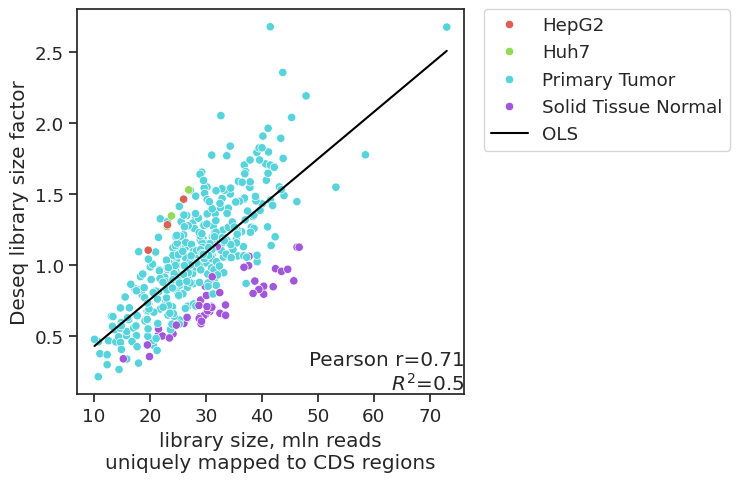

In [17]:
import statsmodels.api as sm

data = sfs_df.copy()

Y = data["sf"]
X = data["library_size_mln"]
X = sm.add_constant(X)
model = sm.OLS(Y, X)
results = model.fit()
data["tmp"] = results.predict(X)

sns.set(font_scale=1.2)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(5, 5))

hue_order = list(np.sort(data["condition_1"].unique()))
palette = list(sns.color_palette("hls", len(hue_order)))

ax = sns.scatterplot(
    data=data,
    x="library_size_mln",
    y="sf",
    hue="condition_1",
    palette=palette,
    hue_order=hue_order,
)
ax = sns.lineplot(
    data=data, x="library_size_mln", y="tmp", color="black", label="OLS"
)  # OLS

ax.text(
    ax.get_xlim()[1],
    ax.get_ylim()[0],
    "Pearson r="
    + str(np.round(stats.pearsonr(data["sf"], data["library_size_mln"])[0], 2))
    + "\n"
    + "$R^2$="
    + str(np.round(results.rsquared, 2)),
    ha="right",
    va="bottom",
)

ax.tick_params(bottom=True, left=True)
ax.set(
    xlabel="library size, mln reads\nuniquely mapped to CDS regions",
    ylabel="Deseq library size factor",
)
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0, title="")

out = subprocess.check_output(
    "mkdir -p " + subdirs["figures_dir"] + "lincRNA_translation/gene_expression/",
    shell=True,
)
fig.savefig(
    subdirs["figures_dir"]
    + "lincRNA_translation/gene_expression/LibrarySize_vs_deseqSF.png",
    bbox_inches="tight",
    dpi=600,
)

In [18]:
# we want to add gene names and biotypes
gtf_df = pd.read_csv(
    subdirs["wf_runs_dir"]
    + "TCGA_LIHC/annotation/Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.gtf",
    delimiter="\t",
    index_col=None,
    header=None,
    skiprows=0,
)

genes_df = gtf_df.loc[gtf_df[2] == "gene"].reset_index(drop=True)
genes_df["gene_id"] = (
    genes_df[8].str.split('gene_id "', expand=True)[1].str.split('"', expand=True)[0]
)
genes_df["SourceAnnotation_gene_id"] = genes_df["gene_id"].str.split(
    "_|:", expand=True
)[0]
genes_df["ORF_CDS_type"] = genes_df.apply(lambda x: x["gene_id"].split(":")[1], 1)
genes_df["nORF_type"] = genes_df.apply(
    lambda x: (
        x["gene_id"].split(":")[0].split("_")[-1]
        if len(x["gene_id"].split("_")) > 1
        else "CDS"
    ),
    1,
)

In [19]:
# also use GENCODE .gtf to assing reasonable gene_names
GENCODE_gtf_df = pd.read_csv(
    file_paths["human_annotation_file"],
    delimiter="\t",
    index_col=None,
    header=None,
    skiprows=5,
)

# ORF ids involve GENCODE transcript ids, not gene ids!

GENCODE_transcripts_df = GENCODE_gtf_df.loc[
    GENCODE_gtf_df[2] == "transcript"
].reset_index(drop=True)
# we will merge by this value
GENCODE_transcripts_df["SourceAnnotation_gene_id"] = (
    GENCODE_transcripts_df[8]
    .str.split('transcript_id "', expand=True)[1]
    .str.split('"', expand=True)[0]
    .str.split(".", expand=True)[0]
)
# remove trailing .<number> from ids
GENCODE_transcripts_df["GENCODE_gene_id"] = (
    GENCODE_transcripts_df[8]
    .str.split('gene_id "', expand=True)[1]
    .str.split('"', expand=True)[0]
    .str.split(".", expand=True)[0]
)
GENCODE_transcripts_df["GENCODE_gene_name"] = (
    GENCODE_transcripts_df[8]
    .str.split('gene_name "', expand=True)[1]
    .str.split('"', expand=True)[0]
    .str.split(".", expand=True)[0]
)

for col in ["GENCODE_gene_id", "GENCODE_gene_name"]:
    if col in genes_df.columns:
        genes_df = genes_df.drop(col, axis=1)

genes_df = pd.merge(
    genes_df,
    GENCODE_transcripts_df[
        ["SourceAnnotation_gene_id", "GENCODE_gene_id", "GENCODE_gene_name"]
    ],
    how="left",
    on=["SourceAnnotation_gene_id"],
)
# still, there are genes whithout assigned gene_id and gene name

In [20]:
# also use Ensemble .gtf that Meric used in his analysis
Ensemble_gtf_df = pd.read_csv(
    subdirs["wf_runs_dir"]
    + "TCGA_LIHC/annotation/Homo_sapiens.GRCh38.110.chr.with_chr_names.gtf",
    delimiter="\t",
    index_col=None,
    header=None,
    skiprows=0,
)

Ensemble_transcripts_df = Ensemble_gtf_df.loc[
    Ensemble_gtf_df[2] == "transcript"
].reset_index(drop=True)
# we will merge by this value
Ensemble_transcripts_df["SourceAnnotation_gene_id"] = (
    Ensemble_transcripts_df[8]
    .str.split('transcript_id "', expand=True)[1]
    .str.split('"', expand=True)[0]
    .str.split(".", expand=True)[0]
)
# remove trailing .<number> from ids
Ensemble_transcripts_df["Ensemble_gene_id"] = (
    Ensemble_transcripts_df[8]
    .str.split('gene_id "', expand=True)[1]
    .str.split('"', expand=True)[0]
    .str.split(".", expand=True)[0]
)
Ensemble_transcripts_df["Ensemble_gene_name"] = (
    Ensemble_transcripts_df[8]
    .str.split('gene_name "', expand=True)[1]
    .str.split('"', expand=True)[0]
    .str.split(".", expand=True)[0]
)

for col in ["Ensemble_gene_id", "Ensemble_gene_name"]:
    if col in genes_df.columns:
        genes_df = genes_df.drop(col, axis=1)

genes_df = pd.merge(
    genes_df,
    Ensemble_transcripts_df[
        ["SourceAnnotation_gene_id", "Ensemble_gene_id", "Ensemble_gene_name"]
    ],
    how="left",
    on=["SourceAnnotation_gene_id"],
)

genes_df = genes_df.drop_duplicates(["gene_id"]).reset_index(drop=True)

In [21]:
len(genes_df), len(genes_df.loc[genes_df["GENCODE_gene_id"].isna()]), len(
    genes_df.loc[genes_df["Ensemble_gene_id"].isna()]
)

(35613, 7028, 6908)

In [22]:
# the following is the genes dataframe to be used for merging with count data
MergeReady_genes_df = genes_df[
    [
        "gene_id",
        "ORF_CDS_type",
        "nORF_type",
        "SourceAnnotation_gene_id",
        "GENCODE_gene_id",
        "GENCODE_gene_name",
        "Ensemble_gene_id",
        "Ensemble_gene_name",
    ]
].rename(columns={"gene_id": "Geneid"})

In [139]:
# get normalized counts (using Deseq size factors)

# make sure the sample order would be correct
if sfs_df.index.name != "sample":
    sfs_df = sfs_df.set_index("sample")
aligned_sfs = sfs_df.loc[samples_list, "sf"]

# Calculate normalized counts
pseudocount = 1
norm_CountMatrix_df = (raw_CountMatrix_df[samples_list] + pseudocount).div(
    aligned_sfs, axis=1
)

# Concatenate back
matrix_index_cols = ["Geneid", "chr", "strand", "Start", "End", "Length"]
norm_CountMatrix_df = pd.concat(
    [raw_CountMatrix_df[matrix_index_cols], norm_CountMatrix_df], axis=1
)

# save norm counts
out = subprocess.check_output(
    "mkdir -p " + subdirs["tables_dir"] + "lincRNA_translation/gene_expression/",
    shell=True,
)
data = pd.merge(MergeReady_genes_df, norm_CountMatrix_df, how="inner", on="Geneid")
data.to_csv(
    subdirs["tables_dir"]
    + "lincRNA_translation/gene_expression/deseq_norm_gene_counts.CDS_nORFs.all_samples.tsv",
    sep=str("\t"),
    header=True,
    index=None,
    quoting=csv.QUOTE_NONE,
)

In [141]:
# calculate mean NORMALIZED values per etiology group, for comparisong with downstream results!

condition_feature = "etiology_group"
condition_vals = list(sample_metadata_df[condition_feature].unique())

matrix_index_cols = ["Geneid", "chr", "strand", "Start", "End", "Length"]
OverGroup_expression_df = pd.DataFrame(
    [
        norm_CountMatrix_df[
            list(
                sample_metadata_df.loc[sample_metadata_df[condition_feature] == elem][
                    "sample"
                ]
            )
        ].mean(axis=1)
        for elem in condition_vals
    ]
).transpose()
OverGroup_expression_df.columns = condition_vals

# do another round of normalization, because sfs could be associated with conditions!
# first, do again deseq normalization
OverGroup_expression_df["min"] = OverGroup_expression_df[condition_vals].min(axis=1)
data_subsel_df = OverGroup_expression_df.loc[
    (OverGroup_expression_df["min"] > OverGroup_expression_df["min"].quantile(0.75))
].reset_index(
    drop=True
)  # take well expressed genes-only
data_subsel_df["geom_mean"] = data_subsel_df[condition_vals].prod(axis=1) ** (
    1 / len(condition_vals)
)
sfs_condition_groups = (
    data_subsel_df[condition_vals].div(data_subsel_df["geom_mean"], axis=0).median()
)

sfs_condition_groups_df = pd.DataFrame(sfs_condition_groups, columns=["sf"])
sfs_condition_groups_df[condition_feature] = sfs_condition_groups_df.index

# make sure the sample order would be correct
sfs_condition_groups_df = sfs_condition_groups_df.set_index(condition_feature)
aligned_sfs_condition_groups = sfs_condition_groups_df.loc[condition_vals, "sf"]

# Calculate normalized counts
norm_OverGroup_expression_df = (OverGroup_expression_df[condition_vals]).div(
    aligned_sfs_condition_groups, axis=1
)
norm_OverGroup_expression_df = pd.concat(
    [norm_CountMatrix_df[matrix_index_cols], norm_OverGroup_expression_df], axis=1
)

# Calculate TPM values
OverGroup_expression_df = pd.concat(
    [norm_CountMatrix_df[matrix_index_cols], OverGroup_expression_df], axis=1
)
TPM_OverGroup_expression_df = OverGroup_expression_df.copy()
TPM_OverGroup_expression_df[condition_vals] = TPM_OverGroup_expression_df[
    condition_vals
].div(TPM_OverGroup_expression_df["Length"], axis=0)
TPM_OverGroup_expression_df[condition_vals] = (
    TPM_OverGroup_expression_df[condition_vals].div(
        TPM_OverGroup_expression_df[condition_vals].sum(), axis=1
    )
    * 10**6
)

if "min" in TPM_OverGroup_expression_df.columns:
    TPM_OverGroup_expression_df = TPM_OverGroup_expression_df.drop(["min"], axis=1)
if "min" in norm_OverGroup_expression_df.columns:
    norm_OverGroup_expression_df = norm_OverGroup_expression_df.drop(["min"], axis=1)

print(len(TPM_OverGroup_expression_df), len(norm_OverGroup_expression_df))

data = pd.merge(
    MergeReady_genes_df, norm_OverGroup_expression_df, how="inner", on="Geneid"
)
data.to_csv(
    subdirs["tables_dir"]
    + "lincRNA_translation/gene_expression/deseq_norm_gene_counts.CDS_nORFs.mean_per_"
    + condition_feature
    + ".tsv",
    sep=str("\t"),
    header=True,
    index=None,
    quoting=csv.QUOTE_NONE,
)

data = pd.merge(
    MergeReady_genes_df, TPM_OverGroup_expression_df, how="inner", on="Geneid"
)
data.to_csv(
    subdirs["tables_dir"]
    + "lincRNA_translation/gene_expression/TPM_gene_counts.CDS_nORFs.mean_per_"
    + condition_feature
    + ".tsv",
    sep=str("\t"),
    header=True,
    index=None,
    quoting=csv.QUOTE_NONE,
)

28235 28235


In [143]:
# get also a table with TPM values
matrix_index_cols = ["Geneid", "chr", "strand", "Start", "End", "Length"]

TPM_res = raw_CountMatrix_df[matrix_index_cols + samples_list].reset_index(drop=True)
TPM_res[samples_list] = TPM_res[samples_list].div(TPM_res["Length"], axis=0)
TPM_res[samples_list] = (
    TPM_res[samples_list].div(TPM_res[samples_list].sum(), axis=1) * 10**6
)

# save TPM values
out = subprocess.check_output(
    "mkdir -p " + subdirs["tables_dir"] + "lincRNA_translation/gene_expression/",
    shell=True,
)
data = pd.merge(MergeReady_genes_df, TPM_res, how="right", on="Geneid")
data.to_csv(
    subdirs["tables_dir"]
    + "lincRNA_translation/gene_expression/TPM_gene_counts.CDS_nORFs.all_samples.tsv",
    sep=str("\t"),
    header=True,
    index=None,
    quoting=csv.QUOTE_NONE,
)

### PCA for TCGA from different etiologies vs our Cell line data

In [ ]:
# add group-aggregates, to double-check in PCA that they represent some kind of average!

In [147]:
# we will use log2 expression values for PCA analysis
log2_PCA_norm_CountMatrix_df = pd.concat(
    [norm_CountMatrix_df, norm_OverGroup_expression_df[condition_vals]], axis=1
)
log2_PCA_norm_CountMatrix_df[samples_list + condition_vals] = np.log2(
    log2_PCA_norm_CountMatrix_df[samples_list + condition_vals]
)

In [176]:
def get_MultiDimR2(x, sample_order_df, hue, hue_order, R2adjusted=True):
    # this is actually exactly the R2 from PERMANOVA

    centroid = np.mean(x, axis=0)
    all_distances = pairwise_distances(
        x,
        [centroid],
        metric="sqeuclidean",
    )
    TSS = np.sum(all_distances)

    RSS = 0
    for hue_cat in hue_order:
        l = list(sample_order_df.loc[sample_order_df[hue] == hue_cat]["index"])
        hue_cat_centroid = np.mean(x[l], axis=0)
        hue_cat_distances = pairwise_distances(
            x[l],
            [hue_cat_centroid],
            metric="sqeuclidean",
        )
        RSS = RSS + np.sum(hue_cat_distances)
    if R2adjusted:
        df_RSS = len(x) - len(hue_order) - 1
        df_total = len(x) - 1
        R2 = 1 - (RSS / df_RSS) / (TSS / df_total)
    else:
        R2 = 1 - RSS / TSS

    return R2


def pca_plot(
    data_df,
    samples_list,
    metadata_df,
    hue_feature,
    savefig_path,
    sns_color_palette="hls",
    plot_lims=None,
    legend_title="",
    highlight_samples_list=None,
):
    # assumes that data_df is gene expression matrix with genes in rows and samples in columns
    # and may be having additional columns like "gene length" etc
    # therefore, "samples_list" should match column names

    x = (data_df[samples_list].values).transpose()
    x = StandardScaler().fit_transform(x)

    pca = PCA(n_components=2)
    principalComponents = pca.fit_transform(x)
    principalDf = pd.DataFrame(data=principalComponents, columns=["PC1", "PC2"])
    principalDf["sample"] = samples_list
    principalDf = pd.merge(principalDf, metadata_df, how="left", on="sample")

    x_feature, y_feature = "PC1", "PC2"
    hue = hue_feature
    hue_order = list(np.sort(metadata_df[hue].unique()))
    palette = list(sns.color_palette(sns_color_palette, len(hue_order)))

    ###
    # PCA-only
    ###

    bw_adjust = 1.75
    alpha_param, s_param = 0.9, 10
    sns.set(font_scale=1.2)
    sns.set_style("white")
    fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(5.2, 5.2))

    ax = sns.scatterplot(
        data=principalDf,
        x=x_feature,
        y=y_feature,
        s=s_param,
        alpha=alpha_param,
        edgecolor="black",
        linewidth=0.3,
        hue=hue,
        hue_order=hue_order,
        palette=palette,
    )
    if highlight_samples_list is not None:
        highlight_principalDf = principalDf.loc[
            principalDf["sample"].isin(highlight_samples_list)
        ].reset_index(drop=True)
        ax = sns.scatterplot(
            data=highlight_principalDf,
            x=x_feature,
            y=y_feature,
            s=s_param * 10,
            alpha=0.9,
            edgecolor="black",
            linewidth=1,
            hue=hue,
            hue_order=hue_order,
            palette=palette,
            legend=False,
        )

    k = 0
    for cat in hue_order:
        ax = sns.kdeplot(
            data=principalDf.loc[principalDf[hue] == cat],
            x=x_feature,
            y=y_feature,
            fill=False,
            levels=[0.25],
            bw_adjust=bw_adjust,
            color=palette[k],
        )
        k = k + 1

    ax.set(
        xlabel="PC1, "
        + str(int(np.round(pca.explained_variance_ratio_[0] * 100, 0)))
        + "% variance"
    )
    ax.set(
        ylabel="\nPC2, "
        + str(int(np.round(pca.explained_variance_ratio_[1] * 100, 0)))
        + "% variance"
    )
    ax.set(title=str(len(data_df)) + " top expressed genes")
    if plot_lims is not None:
        ax.set(xlim=plot_lims[0], ylim=plot_lims[1])
    ax.tick_params(bottom=True, left=True)
    ax.legend(
        bbox_to_anchor=(1.05, 1),
        loc=2,
        borderaxespad=0.0,
        title=legend_title,
        markerscale=2.5,
        ncol=1,
    )

    dir_path = Path(savefig_path).parent

    out = subprocess.check_output(
        "mkdir -p " + str(dir_path),
        shell=True,
    )
    fig.savefig(
        savefig_path,
        bbox_inches="tight",
        dpi=600,
    )

In [149]:
# we will try different kinds of metadata labels for PCA plots
PCA_metadata_df = sample_metadata_df.copy()
TCGA_features = ["gender", "histopathologic_grade"]

PCA_metadata_df = pd.merge(
    PCA_metadata_df,
    TCGA_sample_metadata_df[["sample_submitter_id"] + TCGA_features].rename(
        columns={"sample_submitter_id": "sample"}
    ),
    how="left",
    on=["sample"],
)

for TCGA_feature in TCGA_features:
    PCA_metadata_df[TCGA_feature] = PCA_metadata_df.apply(
        lambda x: x[TCGA_feature] if not pd.isna(x[TCGA_feature]) else x["condition_1"],
        1,
    )

PCA_metadata_df["histopathologic_grade"] = PCA_metadata_df.apply(
    lambda x: (
        "0_NT"
        if x["condition_1"] == "Solid Tissue Normal"
        else x["histopathologic_grade"]
    ),
    1,
)
PCA_metadata_df = pd.merge(
    PCA_metadata_df, sfs_df[["sf"]], how="left", left_on=["sample"], right_index=True
)
PCA_metadata_df["sf_qcut"] = pd.qcut(PCA_metadata_df["sf"], 5)
PCA_metadata_df["library_size_mln_qcut"] = pd.qcut(
    PCA_metadata_df["library_size_mln"], 5
)

In [154]:
# that's to trace group-averages
Condition_averages_metadata_df = pd.DataFrame(condition_vals, columns=["sample"])
Condition_averages_metadata_df["etiology_group"] = (
    Condition_averages_metadata_df["sample"] + " - group average"
)

PCA_metadata_with_condition_averages_df = pd.concat(
    [
        PCA_metadata_df[["sample", "etiology_group"]],
        Condition_averages_metadata_df[["sample", "etiology_group"]],
    ]
).reset_index(drop=True)

In [158]:
# for removing low-expressed genes
log2_PCA_norm_CountMatrix_df["log2_expected_CPM"] = log2_PCA_norm_CountMatrix_df[
    condition_vals
].mean(axis=1)

19764


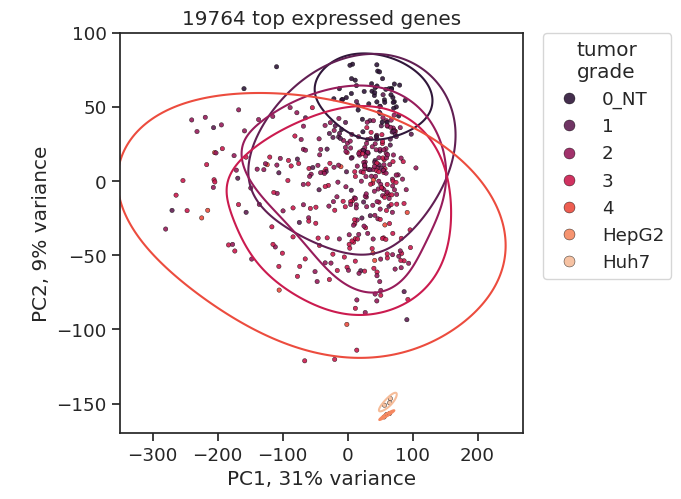

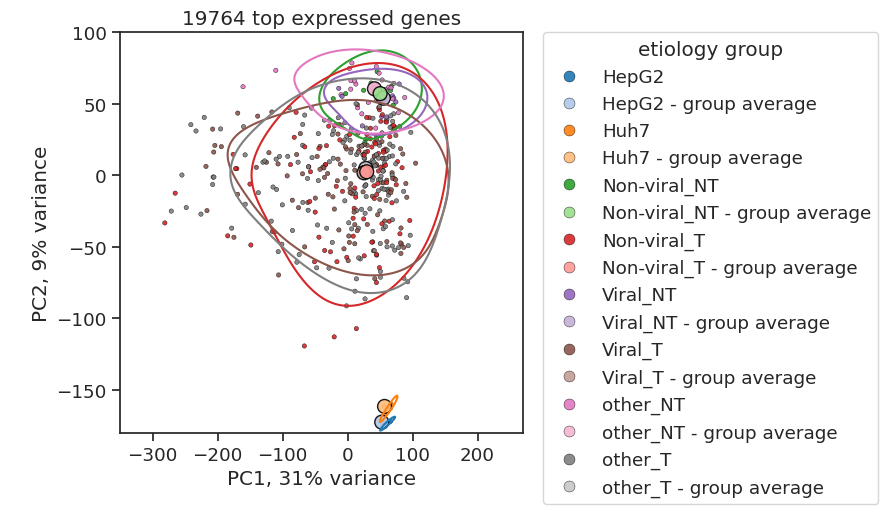

In [177]:
PCA_UMAP_subset = log2_PCA_norm_CountMatrix_df.loc[
    (
        log2_PCA_norm_CountMatrix_df["log2_expected_CPM"]
        > log2_PCA_norm_CountMatrix_df["log2_expected_CPM"].quantile(0.3)
    )
].reset_index(drop=True)
# exclude bottom 20% lowest expressed genes
print(len(PCA_UMAP_subset))

savefig_path = (
    subdirs["figures_dir"]
    + "lincRNA_translation/gene_expression/PCA_gene_expression.histopathologic_grade.png"
)
pca_plot(
    PCA_UMAP_subset,
    samples_list,
    PCA_metadata_df,
    "histopathologic_grade",
    savefig_path,
    "rocket",
    ((-350, 270), (-170, 100)),
    "tumor\ngrade",
)

savefig_path = (
    subdirs["figures_dir"]
    + "lincRNA_translation/gene_expression/PCA_gene_expression.etiology_group.png"
)
pca_plot(
    PCA_UMAP_subset,
    samples_list + condition_vals,
    PCA_metadata_with_condition_averages_df,
    "etiology_group",
    savefig_path,
    "tab20",
    ((-350, 270), (-180, 100)),
    "etiology group",
    condition_vals,
)

### create "kent_tools" conda env

In [236]:
# these are the set of tools developped by Jim Kent in UCSC

In [73]:
# install conda env with snakemake (also installs python and pandas)
command = "conda create -c conda-forge -c bioconda -n kent_tools"
print(command)

conda create -c conda-forge -c bioconda -n kent_tools


In [72]:
# conda activate kent_tools
command = 'conda install bioconda::ucsc-bigwigtobedgraph '+\
            'bioconda::ucsc-bedgraphtobigwig bioconda::ucsc-bigwigmerge '+\
            'bioconda::ucsc-bigwigaverageoverbed bioconda::ucsc-fatotwobit '+\
            'bioconda::ucsc-twobitinfo bioconda::ucsc-bedtobigbed bioconda::ucsc-genepredtobiggenepred '+\
            'bioconda::ucsc-gtftogenepred -y'
print(command)

conda install bioconda::ucsc-bigwigtobedgraph bioconda::ucsc-bedgraphtobigwig bioconda::ucsc-bigwigmerge bioconda::ucsc-bigwigaverageoverbed bioconda::ucsc-fatotwobit bioconda::ucsc-twobitinfo bioconda::ucsc-bedtobigbed bioconda::ucsc-genepredtobiggenepred bioconda::ucsc-gtftogenepred -y


### Prepare characteristic bigwig coverages for condition groups

<Axes: xlabel='sf', ylabel='Density'>

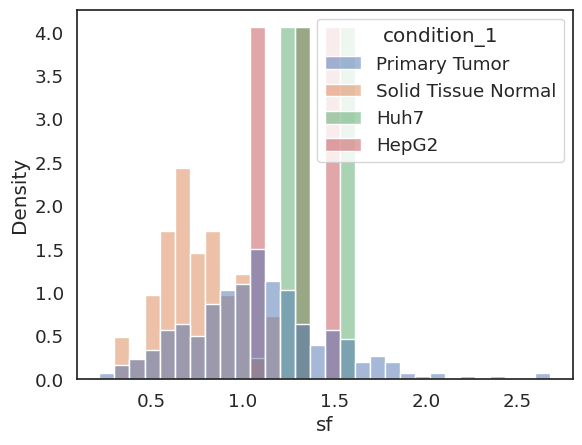

In [187]:
sns.histplot(
    data=sfs_df,
    x="sf",
    hue="condition_1",
    common_norm=False,
    common_bins=True,
    stat="density",
    bins=30,
)

In [237]:
# account for different abundance of samples per category - modify accordingly the size factors for bigwig aggregation!
condition_feature = "etiology_group"
condition_vals = list(sample_metadata_df[condition_feature].unique())

sample_metadata_forBigWigs_df = pd.merge(
    sample_metadata_df, sfs_df[["sf"]], how="inner", left_on="sample", right_index=True
)

sample_metadata_forBigWigs_df["t"] = 1
gr_samples_df = (
    sample_metadata_forBigWigs_df.groupby(condition_feature)
    .agg({"t": np.sum})
    .reset_index()
)
gr_samples_df["TotalNumberOfSamples"] = gr_samples_df["t"]
sample_metadata_forBigWigs_df = pd.merge(
    sample_metadata_forBigWigs_df,
    gr_samples_df[[condition_feature, "TotalNumberOfSamples"]],
    how="inner",
    on=[condition_feature],
)

# additionally, we will need to account for second-round size factors (final normalization between groups)!
sample_metadata_forBigWigs_df = pd.merge(
    sample_metadata_forBigWigs_df,
    sfs_condition_groups_df[["sf"]].rename(columns={"sf": "sf_group"}),
    how="inner",
    left_on=condition_feature,
    right_index=True,
)

sample_metadata_forBigWigs_df["sf_Adjusted"] = (
    sample_metadata_forBigWigs_df["TotalNumberOfSamples"]
    * sample_metadata_forBigWigs_df["sf"]
    * sample_metadata_forBigWigs_df["sf_group"]
)  # now we've adjusted for different number of samples in different groups, and for the final size factors between groups

# we are going to scale down sfs, because otherwise normalized values will be too small (after dividing by size factor values)
ScaleDownFactor = sample_metadata_forBigWigs_df["sf_Adjusted"].quantile(
    0.5
)  # this we will need to transform back such that they will have reasonable library-size-like numbers
print(ScaleDownFactor)
sample_metadata_forBigWigs_df["sf_final"] = sample_metadata_forBigWigs_df[
    "sf_Adjusted"
] / (ScaleDownFactor)

115.27014171141275


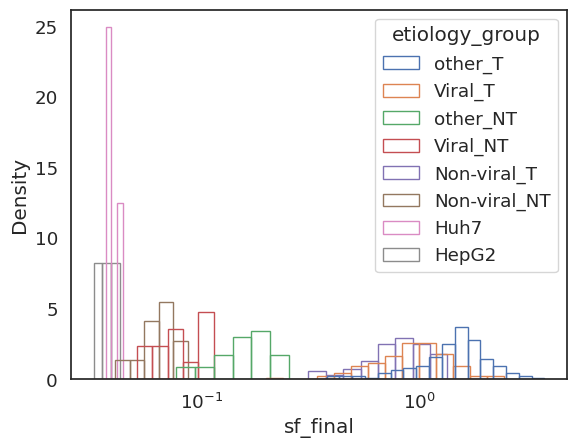

In [238]:
ax = sns.histplot(
    data=sample_metadata_forBigWigs_df,
    x="sf_final",
    hue=condition_feature,
    hue_order=condition_vals,
    common_norm=False,
    common_bins=False,
    stat="density",
    fill=False,
    log_scale=True,
    linewidth=1,
)

#### make bigwig normalization in slurm jobs for our RNA-seqs part (STRANDED)

In [314]:
# collect .bigwig paths for our Cell line RNA-seqs and run normalization of .bigwig files

organism = "human"
WF_version = "Asiers_HepG2_Huh7_RNAseq_v1"

out = subprocess.check_output(
    """find """
    + subdirs["wf_runs_dir"]
    + WF_version
    + "/output/genomic_coverage/"
    + """ -name '*.bigwig' > """
    + subdirs["temp_dir"]
    + """GenomicCoverageBigwig.files.txt""",
    shell=True,
)

GenomicCoverageBigwig_files_df = pd.read_csv(
    subdirs["temp_dir"] + "GenomicCoverageBigwig.files.txt",
    delimiter="\t",
    index_col=None,
    header=None,
)

GenomicCoverageBigwig_files_df["sample"] = GenomicCoverageBigwig_files_df.apply(
    lambda x: x[0]
    .split("/")[-1]
    .replace(".minus.bigwig", "")
    .replace(".plus.bigwig", ""),
    1,
)

GenomicCoverageBigwig_files_df = GenomicCoverageBigwig_files_df.rename(
    columns={0: "file_path"}
)

GenomicCoverageBigwig_files_df["plus"] = GenomicCoverageBigwig_files_df.apply(
    lambda x: "plus" if x["file_path"].endswith(".plus.bigwig") else "minus", 1
)
# we have separate files for each of the strands, and that's correct!

out_dir = (
    subdirs["wf_runs_dir"] + WF_version + "/output/LS_normalized_genomic_coverage/"
)
os.system("mkdir -p " + out_dir)
array_job_table = (
    subdirs["temp_dir"] + "specification_for_LS_normalization.our_RNAseq.tsv"
)

job_specification_df = GenomicCoverageBigwig_files_df.copy()
job_specification_df = pd.merge(
    job_specification_df, sample_metadata_forBigWigs_df, how="inner", on=["sample"]
)

job_specification_df["bedgraph_file_temp"] = (
    out_dir
    + job_specification_df["sample"]
    + "."
    + job_specification_df["plus"]
    + ".bedgraph"
)
job_specification_df["bedgraph_file_normalized_temp"] = (
    out_dir
    + job_specification_df["sample"]
    + "."
    + job_specification_df["plus"]
    + ".normalized.bedgraph"
)
job_specification_df["bigwig_file_normalized"] = (
    out_dir
    + job_specification_df["sample"]
    + "."
    + job_specification_df["plus"]
    + ".normalized.bw"
)

job_specification_df["id"] = job_specification_df.index + 1
job_specification_df[
    [
        "id",
        "file_path",
        "bedgraph_file_temp",
        "bedgraph_file_normalized_temp",
        "bigwig_file_normalized",
        "sf_final",
    ]
].to_csv(array_job_table, sep=str("\t"), header=False, index=None)

chrom_sizes_file = subdirs["wf_runs_dir"] + "TCGA_LIHC/Recount_bigwigs/hg38.chrom.sizes"

sbatch_script_path = (
    subdirs["slurm_scripts_dir"] + "LS_normalization_bigwigs.ourRNAseq.sbatch"
)
# create slurm script for LS_normalization of bigwigs
f = open(sbatch_script_path, "w")
preambula = (
    """#!/bin/bash

#SBATCH --job-name=LS_normalization_bigwigs_ourRNAseq
#SBATCH --partition=scicore
#SBATCH --time=01:00:00
#SBATCH --output="""
    + subdirs["slurm_dir"]
    + """%A_%a.out
#SBATCH --error="""
    + subdirs["slurm_dir"]
    + """%A_%a.err
#SBATCH --cpus-per-task=1 #Number of cores to reserve
#SBATCH --mem=15G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""
    + str(len(job_specification_df))
    + """%150

source ~/.bashrc
conda activate kent_tools
"""
)
f.write(preambula + "\n")
f.write(
    """input_bw=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """
    + array_job_table
    + ")\n"
)
f.write(
    """bedgraph_file_temp=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """
    + array_job_table
    + ")\n"
)
f.write(
    """bedgraph_file_normalized_temp=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $4} }' """
    + array_job_table
    + ")\n"
)
f.write(
    """bigwig_file_normalized=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $5} }' """
    + array_job_table
    + ")\n"
)
f.write(
    """sf_final=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $6} }' """
    + array_job_table
    + ")\n"
)
f.write("""echo $input_bw""" + "\n")

command = (
    "bigWigToBedGraph $input_bw $bedgraph_file_temp && "
    + """awk -F'\\t' -v c=$sf_final 'BEGIN{OFS="\\t"} {$4 = sprintf("%.1f", $4 / c); print}' $bedgraph_file_temp > $bedgraph_file_normalized_temp && """
    + "bedGraphToBigWig $bedgraph_file_normalized_temp "
    + chrom_sizes_file
    + " $bigwig_file_normalized && "
    + "rm $bedgraph_file_temp $bedgraph_file_normalized_temp; "
)
f.write(command)
f.close()
print("sbatch " + sbatch_script_path)

# check that normalized files exist, and exlude those that do not
job_specification_df["bigwig_file_normalized_exists"] = job_specification_df[
    "bigwig_file_normalized"
].apply(lambda x: os.path.exists(x) and os.path.getsize(x) > 0)
print(len(job_specification_df))
print(
    len(job_specification_df.loc[job_specification_df["bigwig_file_normalized_exists"]])
)

sbatch /scicore/home/zavolan/GROUP/CRISPR_projects/scripts/LS_normalization_bigwigs.ourRNAseq.sbatch
12
12


In [317]:
condition_feature = "etiology_group"
condition_vals = list(job_specification_df[condition_feature].unique())

out_dir = (
    subdirs["wf_runs_dir"]
    + WF_version
    + "/output/LS_normalized_genomic_coverage/per_"
    + condition_feature
    + "/"
)
os.system("mkdir -p " + out_dir)

# only include the files that exist and have reasonable size
gr_df = (
    job_specification_df.loc[job_specification_df["bigwig_file_normalized_exists"]]
    .groupby(["plus", condition_feature])["bigwig_file_normalized"]
    .agg(lambda x: '" "'.join(x))
    .reset_index()
)
gr_df["bigwig_file_normalized"] = '"' + gr_df["bigwig_file_normalized"] + '"'
gr_df["temp_bigwig"] = (
    out_dir + gr_df["plus"] + "." + gr_df[condition_feature] + ".temp.bigwig"
)  # conversion to bigwig flattens the signal from overlapping regions
gr_df["out_bedgraph"] = (
    out_dir + gr_df["plus"] + "." + gr_df[condition_feature] + ".bedgraph"
)
gr_df["out_bigwig"] = out_dir + gr_df["plus"] + "." + gr_df[condition_feature] + ".bw"

# define chromosomes to be separated to
# better use another file with chromosome sizes, from the dictionary at the beginning of the jupyter notebook
chromosomes_df = pd.read_csv(
    subdirs["wf_runs_dir"] + "TCGA_LIHC/Recount_bigwigs/hg38.chrom.sizes",
    delimiter="\t",
    index_col=None,
    header=None,
)
chromosome_list = list(
    chromosomes_df.loc[
        (chromosomes_df[0].str.startswith("chr"))
        & (chromosomes_df[0].str.len().isin([4, 5]))
    ][0]
)

# create slurm script for merging LS-normalized files into defined categories, and optionally further separate by chromosome (not necessary for nor, for "hugging face" submission)!

sbatch_scripts = []

chrom_sizes_file = subdirs["wf_runs_dir"] + "TCGA_LIHC/Recount_bigwigs/hg38.chrom.sizes"

out_bw_files_for_OnlineRepo = []

RevertCoef_toUse = np.round(
    ScaleDownFactor, 10
)  # we need to DIVIDE obtained coverage by that value, to make final coverage of reasonable height
print(RevertCoef_toUse)

for index, row in gr_df.iterrows():

    preambula = (
        """#!/bin/bash

#SBATCH --job-name="""
        + row["plus"]
        + "."
        + row[condition_feature]
        + """.our_RNAseq.merge_bigwigs_and_separate_into_chromosomes
#SBATCH --partition=scicore
#SBATCH --qos=6hours
#SBATCH --time=05:50:00
#SBATCH --output="""
        + subdirs["slurm_dir"]
        + row["plus"]
        + "."
        + row[condition_feature]
        + """.our_RNAseq.merge_bigwigs_and_separate_into_chromosomes.out
#SBATCH --error="""
        + subdirs["slurm_dir"]
        + row["plus"]
        + "."
        + row[condition_feature]
        + """.our_RNAseq.merge_bigwigs_and_separate_into_chromosomes.err
#SBATCH --cpus-per-task=15 #Number of cores to reserve
#SBATCH --mem=80G     #Amount of RAM/core to reserve

source ~/.bashrc
conda activate kent_tools

set -e # Stop immediately if any command fails
ulimit -n 10000 # allow opening up to 10K files (important for successful merging with bigWigMerge)
"""
    )

    # create individual sbatch scripts for these different sample categories
    command = ""
    sbatch_file_path = (
        subdirs["slurm_scripts_dir"]
        + row["plus"]
        + "."
        + row[condition_feature]
        + ".our_RNAseq.merge_bigwigs_and_separate_into_chromosomes.sbatch"
    )
    f = open(sbatch_file_path, "w")
    f.write(preambula + "\n")

    temp_unsorted_bedgraph = (
        "$TMPDIR/"
        + row["plus"]
        + "."
        + row[condition_feature]
        + ".all_chromosomes.bedgraph"
    )  # get after merging
    temp_sorted_bedgraph = (
        "$TMPDIR/"
        + row["plus"]
        + "."
        + row[condition_feature]
        + ".all_chromosomes.sorted.bedgraph"
    )  # get after sorting

    command = (
        command
        + "bigWigMerge "
        + row["bigwig_file_normalized"]
        + " "
        + temp_unsorted_bedgraph
        + " && "
        + "sort -k1,1 -k2,2n "
        + temp_unsorted_bedgraph
        + " | "
        + """awk -F'\\t' -v c="""
        + str(RevertCoef_toUse)
        + """ 'BEGIN{OFS="\\t"} {$4 = sprintf("%.10f", $4 / c); print}'"""
        + " > "
        + temp_sorted_bedgraph
        + " && "
        + "bedGraphToBigWig "
        + temp_sorted_bedgraph
        + " "
        + chrom_sizes_file
        + " "
        + row["out_bigwig"]
        + "\n\n"
    )

    # for a moment, we don't need chromosome-separation because Hugging Face nicely deals with large files
    # for k, chromosome in enumerate(chromosome_list):
    #     out_bw_file = subdirs['wf_runs_dir']+'TCGA_LIHC/Recount_bigwigs/per_sample_category/per_chromosome/'+chromosome+'.'+row[condition_feature]+'.bw'
    #     # out_bedgraph_file = subdirs['wf_runs_dir']+'TCGA_LIHC/Recount_bigwigs/per_sample_category/per_chromosome/'+chromosome+'.'+row[condition_feature]+'.bedgraph'
    #     # out_bw_file = subdirs['wf_runs_dir']+'TCGA_LIHC/Recount_bigwigs/per_sample_category/per_chromosome/'+chromosome+'.'+row[condition_feature]+'.bw'
    #     # command = command + """(awk 'BEGIN{OFS="\\t"} {$1 = \""""+chromosome+"""\"; print}' """+row['out_bedgraph']+' | sort -k1,1 -k2,2n > '+out_bedgraph_file+' && ' + \
    #     #         'bedGraphToBigWig '+out_bedgraph_file+' '+subdirs['wf_runs_dir']+'TCGA_LIHC/Recount_bigwigs/hg38.chrom.sizes '+out_bw_file+' && '+ \
    #     #                 'rm '+out_bedgraph_file+'; ) '
    #     temporary_bedgraph = '$TMPDIR/temp.'+chromosome+'.'+row[condition_feature]+'.bedgraph'
    #     command = command + '(bigWigToBedGraph -chrom="'+chromosome+'" '+row['out_bigwig']+' '+temporary_bedgraph+' && '+\
    #                 'bedGraphToBigWig '+temporary_bedgraph+' '+chrom_sizes_file+' '+out_bw_file+' && '+\
    #                 'rm '+temporary_bedgraph+')'

    #     if k<(len(chromosome_list)-1):
    #         command = command + ' & '
    #     else:
    #         command = command + '\n\nwait\n\n'

    command = (
        command + "rm " + temp_unsorted_bedgraph + " " + temp_sorted_bedgraph + "\n"
    )
    f.write(command)
    f.close()

    out_bw_files_for_OnlineRepo.append(
        row["out_bigwig"]
    )  # save to further copy to OnlineRepo

    sbatch_scripts.append(sbatch_file_path)

print("; ".join(["sbatch " + elem for elem in sbatch_scripts]))

115.2701417114
sbatch /scicore/home/zavolan/GROUP/CRISPR_projects/scripts/minus.HepG2.our_RNAseq.merge_bigwigs_and_separate_into_chromosomes.sbatch; sbatch /scicore/home/zavolan/GROUP/CRISPR_projects/scripts/minus.Huh7.our_RNAseq.merge_bigwigs_and_separate_into_chromosomes.sbatch; sbatch /scicore/home/zavolan/GROUP/CRISPR_projects/scripts/plus.HepG2.our_RNAseq.merge_bigwigs_and_separate_into_chromosomes.sbatch; sbatch /scicore/home/zavolan/GROUP/CRISPR_projects/scripts/plus.Huh7.our_RNAseq.merge_bigwigs_and_separate_into_chromosomes.sbatch


In [319]:
len(out_bw_files_for_OnlineRepo)

4

In [320]:
ourRNAseq_tracks_list = out_bw_files_for_OnlineRepo  # save to include to a hub

with open(subdirs["temp_dir"] + "ourRNAseq_tracks_list.txt", "w") as f:
    f.write("\n".join(ourRNAseq_tracks_list) + "\n")

#### make bigwig normalization in slurm jobs for TCGA part (UNSTRANDED)

In [290]:
out_dir = subdirs["wf_runs_dir"] + "TCGA_LIHC/Recount_bigwigs/LS_normalization/"
os.system("mkdir -p " + out_dir)
array_job_table = subdirs["temp_dir"] + "specification_for_LS_normalization.tsv"

job_specification_df = sample_metadata_forBigWigs_df.copy()
job_specification_df = pd.merge(
    job_specification_df,
    TCGA_etiology_metadata_df.rename(columns={"sample_submitter_id": "sample"})[
        ["sample", "file_path"]
    ].copy(),  # see from above
    how="inner",
    on=["sample"],
)

job_specification_df["bedgraph_file_temp"] = (
    out_dir + job_specification_df["sample"] + ".bedgraph"
)
job_specification_df["bedgraph_file_normalized_temp"] = (
    out_dir + job_specification_df["sample"] + ".normalized.bedgraph"
)
job_specification_df["bigwig_file_normalized"] = (
    out_dir + job_specification_df["sample"] + ".normalized.bw"
)

job_specification_df["id"] = job_specification_df.index + 1
job_specification_df[
    [
        "id",
        "file_path",
        "bedgraph_file_temp",
        "bedgraph_file_normalized_temp",
        "bigwig_file_normalized",
        "sf_final",
    ]
].to_csv(array_job_table, sep=str("\t"), header=False, index=None)

chrom_sizes_file = subdirs["wf_runs_dir"] + "TCGA_LIHC/Recount_bigwigs/hg38.chrom.sizes"

# create slurm script for LS_normalization of bigwigs
f = open(subdirs["slurm_scripts_dir"] + "LS_normalization_bigwigs.sbatch", "w")
preambula = (
    """#!/bin/bash

#SBATCH --job-name=LS_normalization_bigwigs
#SBATCH --partition=scicore
#SBATCH --time=01:00:00
#SBATCH --output="""
    + subdirs["slurm_dir"]
    + """%A_%a.out
#SBATCH --error="""
    + subdirs["slurm_dir"]
    + """%A_%a.err
#SBATCH --cpus-per-task=1 #Number of cores to reserve
#SBATCH --mem=15G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""
    + str(len(job_specification_df))
    + """%150

source ~/.bashrc
conda activate kent_tools
"""
)
f.write(preambula + "\n")
f.write(
    """input_bw=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """
    + array_job_table
    + ")\n"
)
f.write(
    """bedgraph_file_temp=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """
    + array_job_table
    + ")\n"
)
f.write(
    """bedgraph_file_normalized_temp=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $4} }' """
    + array_job_table
    + ")\n"
)
f.write(
    """bigwig_file_normalized=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $5} }' """
    + array_job_table
    + ")\n"
)
f.write(
    """sf_final=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $6} }' """
    + array_job_table
    + ")\n"
)
f.write("""echo $input_bw""" + "\n")

command = (
    "bigWigToBedGraph $input_bw $bedgraph_file_temp && "
    + """awk -F'\\t' -v c=$sf_final 'BEGIN{OFS="\\t"} NR==FNR {valid_chroms[$1]=1; next} $1 in valid_chroms {$4 = sprintf("%.1f", $4 / c); print}' """
    + chrom_sizes_file
    + " $bedgraph_file_temp > $bedgraph_file_normalized_temp && "
    + "bedGraphToBigWig $bedgraph_file_normalized_temp "
    + chrom_sizes_file
    + " $bigwig_file_normalized && "
    + "rm $bedgraph_file_temp $bedgraph_file_normalized_temp; "
)

f.write(command)
f.close()
print("sbatch " + subdirs["slurm_scripts_dir"] + "LS_normalization_bigwigs.sbatch")

# check that normalized files exist, and exlude those that do not
job_specification_df["bigwig_file_normalized_exists"] = job_specification_df[
    "bigwig_file_normalized"
].apply(lambda x: os.path.exists(x) and os.path.getsize(x) > 0)
print(len(job_specification_df))
print(
    len(job_specification_df.loc[job_specification_df["bigwig_file_normalized_exists"]])
)

sbatch /scicore/home/zavolan/GROUP/CRISPR_projects/scripts/LS_normalization_bigwigs.sbatch
416
416


In [301]:
condition_feature = "etiology_group"
condition_vals = list(job_specification_df[condition_feature].unique())

os.system(
    """mkdir -p """
    + subdirs["wf_runs_dir"]
    + "TCGA_LIHC/Recount_bigwigs/per_"
    + condition_feature
    + "/per_chromosome/"
)

# only include the files that exist and have reasonable size
gr_df = (
    job_specification_df.loc[job_specification_df["bigwig_file_normalized_exists"]]
    .groupby([condition_feature])["bigwig_file_normalized"]
    .agg(lambda x: '" "'.join(x))
    .reset_index()
)
gr_df["bigwig_file_normalized"] = '"' + gr_df["bigwig_file_normalized"] + '"'
gr_df["temp_bigwig"] = (
    subdirs["wf_runs_dir"]
    + "TCGA_LIHC/Recount_bigwigs/per_"
    + condition_feature
    + "/"
    + gr_df[condition_feature]
    + ".temp.bigwig"
)  # conversion to bigwig flattens the signal from overlapping regions
gr_df["out_bedgraph"] = (
    subdirs["wf_runs_dir"]
    + "TCGA_LIHC/Recount_bigwigs/per_"
    + condition_feature
    + "/"
    + gr_df[condition_feature]
    + ".bedgraph"
)
gr_df["out_bigwig"] = (
    subdirs["wf_runs_dir"]
    + "TCGA_LIHC/Recount_bigwigs/per_"
    + condition_feature
    + "/"
    + gr_df[condition_feature]
    + ".bw"
)

# define chromosomes to be separated to

chromosomes_df = pd.read_csv(
    subdirs["wf_runs_dir"] + "TCGA_LIHC/Recount_bigwigs/hg38.chrom.sizes",
    delimiter="\t",
    index_col=None,
    header=None,
)
chromosome_list = list(
    chromosomes_df.loc[
        (chromosomes_df[0].str.startswith("chr"))
        & (chromosomes_df[0].str.len().isin([4, 5]))
    ][0]
)

# create slurm script for merging LS-normalized files into defined categories, and optionally further separate by chromosome (not necessary for nor, for "hugging face" submission)!

sbatch_scripts = []

chrom_sizes_file = subdirs["wf_runs_dir"] + "TCGA_LIHC/Recount_bigwigs/hg38.chrom.sizes"

out_bw_files_for_OnlineRepo = []

RevertCoef_toUse = np.round(
    ScaleDownFactor, 10
)  # we need to DIVIDE obtained coverage by that value, to make final coverage of reasonable height
print(RevertCoef_toUse)

for index, row in gr_df.iterrows():

    preambula = (
        """#!/bin/bash

#SBATCH --job-name="""
        + row[condition_feature]
        + """.merge_bigwigs_and_separate_into_chromosomes
#SBATCH --partition=scicore
#SBATCH --qos=6hours
#SBATCH --time=05:50:00
#SBATCH --output="""
        + subdirs["slurm_dir"]
        + row[condition_feature]
        + """.merge_bigwigs_and_separate_into_chromosomes.out
#SBATCH --error="""
        + subdirs["slurm_dir"]
        + row[condition_feature]
        + """.merge_bigwigs_and_separate_into_chromosomes.err
#SBATCH --cpus-per-task=15 #Number of cores to reserve
#SBATCH --mem=80G     #Amount of RAM/core to reserve

source ~/.bashrc
conda activate kent_tools

set -e # Stop immediately if any command fails
ulimit -n 10000 # allow opening up to 10K files (important for successful merging with bigWigMerge)
"""
    )

    # create individual sbatch scripts for these different sample categories
    command = ""
    sbatch_file_path = (
        subdirs["slurm_scripts_dir"]
        + row[condition_feature]
        + ".merge_bigwigs_and_separate_into_chromosomes.sbatch"
    )
    f = open(sbatch_file_path, "w")
    f.write(preambula + "\n")

    temp_unsorted_bedgraph = (
        "$TMPDIR/" + row[condition_feature] + ".all_chromosomes.bedgraph"
    )  # get after merging
    temp_sorted_bedgraph = (
        "$TMPDIR/" + row[condition_feature] + ".all_chromosomes.sorted.bedgraph"
    )  # get after sorting

    command = (
        command
        + "bigWigMerge "
        + row["bigwig_file_normalized"]
        + " "
        + temp_unsorted_bedgraph
        + " && "
        + "sort -k1,1 -k2,2n "
        + temp_unsorted_bedgraph
        + " | "
        + """awk -F'\\t' -v c="""
        + str(RevertCoef_toUse)
        + """ 'BEGIN{OFS="\\t"} {$4 = sprintf("%.10f", $4 / c); print}'"""
        + " > "
        + temp_sorted_bedgraph
        + " && "
        + "bedGraphToBigWig "
        + temp_sorted_bedgraph
        + " "
        + chrom_sizes_file
        + " "
        + row["out_bigwig"]
        + "\n\n"
    )

    # for a moment, we don't need chromosome-separation because Hugging Face nicely deals with large files
    # for k, chromosome in enumerate(chromosome_list):
    #     out_bw_file = subdirs['wf_runs_dir']+'TCGA_LIHC/Recount_bigwigs/per_sample_category/per_chromosome/'+chromosome+'.'+row[condition_feature]+'.bw'
    #     # out_bedgraph_file = subdirs['wf_runs_dir']+'TCGA_LIHC/Recount_bigwigs/per_sample_category/per_chromosome/'+chromosome+'.'+row[condition_feature]+'.bedgraph'
    #     # out_bw_file = subdirs['wf_runs_dir']+'TCGA_LIHC/Recount_bigwigs/per_sample_category/per_chromosome/'+chromosome+'.'+row[condition_feature]+'.bw'
    #     # command = command + """(awk 'BEGIN{OFS="\\t"} {$1 = \""""+chromosome+"""\"; print}' """+row['out_bedgraph']+' | sort -k1,1 -k2,2n > '+out_bedgraph_file+' && ' + \
    #     #         'bedGraphToBigWig '+out_bedgraph_file+' '+subdirs['wf_runs_dir']+'TCGA_LIHC/Recount_bigwigs/hg38.chrom.sizes '+out_bw_file+' && '+ \
    #     #                 'rm '+out_bedgraph_file+'; ) '
    #     temporary_bedgraph = '$TMPDIR/temp.'+chromosome+'.'+row[condition_feature]+'.bedgraph'
    #     command = command + '(bigWigToBedGraph -chrom="'+chromosome+'" '+row['out_bigwig']+' '+temporary_bedgraph+' && '+\
    #                 'bedGraphToBigWig '+temporary_bedgraph+' '+chrom_sizes_file+' '+out_bw_file+' && '+\
    #                 'rm '+temporary_bedgraph+')'

    #     if k<(len(chromosome_list)-1):
    #         command = command + ' & '
    #     else:
    #         command = command + '\n\nwait\n\n'

    command = (
        command + "rm " + temp_unsorted_bedgraph + " " + temp_sorted_bedgraph + "\n"
    )
    f.write(command)
    f.close()

    out_bw_files_for_OnlineRepo.append(
        row["out_bigwig"]
    )  # save to further copy to OnlineRepo

    sbatch_scripts.append(sbatch_file_path)

print("; ".join(["sbatch " + elem for elem in sbatch_scripts]))

115.2701417114
sbatch /scicore/home/zavolan/GROUP/CRISPR_projects/scripts/Non-viral_NT.merge_bigwigs_and_separate_into_chromosomes.sbatch; sbatch /scicore/home/zavolan/GROUP/CRISPR_projects/scripts/Non-viral_T.merge_bigwigs_and_separate_into_chromosomes.sbatch; sbatch /scicore/home/zavolan/GROUP/CRISPR_projects/scripts/Viral_NT.merge_bigwigs_and_separate_into_chromosomes.sbatch; sbatch /scicore/home/zavolan/GROUP/CRISPR_projects/scripts/Viral_T.merge_bigwigs_and_separate_into_chromosomes.sbatch; sbatch /scicore/home/zavolan/GROUP/CRISPR_projects/scripts/other_NT.merge_bigwigs_and_separate_into_chromosomes.sbatch; sbatch /scicore/home/zavolan/GROUP/CRISPR_projects/scripts/other_T.merge_bigwigs_and_separate_into_chromosomes.sbatch


In [304]:
len(out_bw_files_for_OnlineRepo)

6

In [305]:
TCGA_LIHC_tracks_list = out_bw_files_for_OnlineRepo  # save to include to a hub

with open(subdirs["temp_dir"] + "TCGA_LIHC_tracks_list.txt", "w") as f:
    f.write("\n".join(TCGA_LIHC_tracks_list) + "\n")

#### preform self-consistency check of final bigwig files

In [ ]:
###
# preform self-consistency check of final .bigwig files:
# extract coverage of particular exons and compare those values with count-based values (obtained with FeatureCounts in snakemake) from above

# Currently: check manually in IGV

In [328]:
# see the following IGV session on sciCORE:
print(subdirs["main_project_dir"] + "IGV/Etiology_group_bigwigs.xml")

/scicore/home/zavolan/GROUP/CRISPR_projects/IGV/Etiology_group_bigwigs.xml


In [323]:
# check e.g. GAPDH loci:
norm_OverGroup_expression_df.loc[
    norm_OverGroup_expression_df["Geneid"].str.contains("229239")
]

,Geneid,chr,strand,Start,End,Length,other_T,Viral_T,other_NT,Viral_NT,Non-viral_T,Non-viral_NT,Huh7,HepG2
1141,ENST00000229239:CDS,chr12,+,6534846;6536536;6536684;6536920;6537101;653730...,6534861;6536593;6536790;6537010;6537216;653739...,950,103426.607991,87257.492409,63856.542781,65834.687404,90383.434771,62519.483837,68596.012313,98288.283294
1142,ENST00000229239_1083_1206_1083_1206_dORF:nORF,chr12,+,6538170,6538292,123,22423.427361,17228.175913,12251.427631,11269.035280,19685.494655,12039.869202,15232.641980,19244.660300
1143,ENST00000229239_14_89_14_89_uORF:nORF,chr12,+,6534531;6534810,6534569;6534832,62,3266.067038,2902.273250,2218.400295,2469.190350,2845.878423,2203.658505,3451.171625,5251.067005


## make hub

use huggginface for development, and then migrate to zenodo for finalized tracks

### Prepare big gene pred from the .gtf file

In [79]:
gtf_df = pd.read_csv(
    subdirs["wf_runs_dir"]
    + "TCGA_LIHC/annotation/Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.gtf",
    delimiter="\t",
    index_col=None,
    header=None,
    skiprows=0,
)
gtf_df[0] = gtf_df[0].str.replace('chrMT','chrM')
gtf_df.to_csv(subdirs["wf_runs_dir"]
    + "TCGA_LIHC/annotation/Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fixed_chromosome_names.gtf",sep=str('\t'),header=False,index=None,quoting=csv.QUOTE_NONE)

In [4]:
# for browsing across targets
gtf_df = pd.read_csv(
    subdirs["wf_runs_dir"]
    + "TCGA_LIHC/annotation/Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fixed_chromosome_names.gtf",
    delimiter="\t",
    index_col=None,
    header=None,
    skiprows=0,
)

gtf_df["gene_id"] = (
    gtf_df[8].str.split('gene_id "', expand=True)[1].str.split('"', expand=True)[0]
)
gtf_df['ucsc_coords'] = gtf_df[0]+':'+gtf_df[3].astype('str')+'-'+gtf_df[4].astype('str')

In [7]:
gtf_df.loc[gtf_df['gene_id'].str.startswith('NONHSAT211539_144_591_144_591_lncRNA')]

,0,1,2,3,4,5,6,7,8,gene_id,ucsc_coords
44212,chr7,CUSTOM,gene,1160518,1164309,.,+,0,"gene_id ""NONHSAT211539_144_591_144_591_lncRNA:...",NONHSAT211539_144_591_144_591_lncRNA:nORF,chr7:1160518-1164309
44213,chr7,CUSTOM,transcript,1160518,1164309,.,+,0,"gene_id ""NONHSAT211539_144_591_144_591_lncRNA:...",NONHSAT211539_144_591_144_591_lncRNA:nORF,chr7:1160518-1164309
44214,chr7,CUSTOM,exon,1160518,1160623,.,+,0,"gene_id ""NONHSAT211539_144_591_144_591_lncRNA:...",NONHSAT211539_144_591_144_591_lncRNA:nORF,chr7:1160518-1160623
44215,chr7,CUSTOM,exon,1162352,1162543,.,+,0,"gene_id ""NONHSAT211539_144_591_144_591_lncRNA:...",NONHSAT211539_144_591_144_591_lncRNA:nORF,chr7:1162352-1162543
44216,chr7,CUSTOM,exon,1164161,1164309,.,+,0,"gene_id ""NONHSAT211539_144_591_144_591_lncRNA:...",NONHSAT211539_144_591_144_591_lncRNA:nORF,chr7:1164161-1164309


In [9]:
chr20:30398045-30398046 - donor
chr20:30404267-30404267 - acceptor

1.4102564102564104

In [13]:
(30404267-30398046+1)

6222

In [43]:
gtf_df['chr'] = gtf_df[0]
gtf_df['strand'] = gtf_df[6]
gtf_df['start'] = gtf_df[3]
gtf_df['end'] = gtf_df[4]

In [65]:
# now, prepare annotation in genePred format, compatible with UCSC
genePred_df = gtf_df.copy()
genePred_df['feature_type'] = "CDS" # we only have ORFs (annotated CDSs and new nORFs)
genePred_df[0] = genePred_df['gene_id']
genePred_df[1] = genePred_df['chr'].str.replace('chrMT','chrM')
genePred_df[2] = genePred_df['strand']
genePred_df[3] = genePred_df['start']
genePred_df[4] = genePred_df['end']
genePred_df[5] = genePred_df.apply(lambda x:(x['start'] if x['feature_type']=='CDS' else 0),1)
genePred_df[6] = genePred_df.apply(lambda x:(x['end'] if x['feature_type']=='CDS' else 0),1)
genePred_df[7] = 1
genePred_df[8] = genePred_df['start']
genePred_df[9] = genePred_df['end']
genePred_df[10] = 0
genePred_df[11] = genePred_df['gene_id']
genePred_df[12] = genePred_df.apply(lambda x:('cmpl' if x['feature_type']=='CDS' else 'unk'),1)
genePred_df[13] = genePred_df.apply(lambda x:('cmpl' if x['feature_type']=='CDS' else 'unk'),1)
genePred_df[14] = genePred_df.apply(lambda x:(0 if x['feature_type']=='CDS' else -1),1)
genePred_df[range(0,15)].to_csv(subdirs['temp_dir']+'Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.genePred',sep=str('\t'),header=False,index=None,quoting=csv.QUOTE_NONE)

In [82]:
# USE kent_tools conda env created above
# conda activate kent_tools

# prepare gene annotation
out_dir = (
    subdirs["UCSCtracks_trackfiles_dir"] + "Annotations/HCC_Translatome/"
)
out = subprocess.check_output("mkdir -p " + out_dir, shell=True)

# run in login node with Web access
command = "cd "+subdirs['temp_dir']+" && wget https://genome.ucsc.edu/goldenpath/help/examples/bigGenePred.as"+'\n\n'
print(command)

# also try to convert just from original .gtf
input_gtf = subdirs["wf_runs_dir"] + "TCGA_LIHC/annotation/Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fixed_chromosome_names.gtf"
command = 'gtfToGenePred -genePredExt '+input_gtf+' '+subdirs['temp_dir']+'Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fromGTF.genePred'+'\n\n'
print(command)

command = 'genePredToBigGenePred '+\
            subdirs['temp_dir']+'Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fromGTF.genePred '+\
            subdirs['temp_dir']+'Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fromGTF.BigGenePred'+'\n\n'
print(command)


command = 'bedToBigBed -sort -type=bed12+8 -tab -as='+subdirs['temp_dir']+'bigGenePred.as '+\
            subdirs['temp_dir']+'Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fromGTF.BigGenePred '+\
            file_paths['human_chrom_sizes_file']+' '+\
            out_dir+'Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fromGTF.bb'+'\n\n'
print(command)

cd /scicore/home/zavolan/GROUP/CRISPR_projects/temp_dir/ && wget https://genome.ucsc.edu/goldenpath/help/examples/bigGenePred.as


gtfToGenePred -genePredExt /scicore/home/zavolan/GROUP/CRISPR_projects/wf_runs/TCGA_LIHC/annotation/Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fixed_chromosome_names.gtf /scicore/home/zavolan/GROUP/CRISPR_projects/temp_dir/Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fromGTF.genePred


genePredToBigGenePred /scicore/home/zavolan/GROUP/CRISPR_projects/temp_dir/Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fromGTF.genePred /scicore/home/zavolan/GROUP/CRISPR_projects/temp_dir/Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fromGTF.BigGenePred


bedToBigBed -sort -type=bed12+8 -tab -as=/scicore/home/zavolan/GROUP/CRISPR_projects/temp_dir/bigGenePred.as /scicore/home/zavolan/GROUP/CRISPR_projects/temp_dir/Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fromGTF.BigGenePred /scicore/home/zavolan/GROUP/Genomes/homo_

### Make .fasta out of the table with selected lincRNA sequences

In [96]:
selected_lncRNAs = pd.read_csv(
    subdirs['tables_dir']+'lincRNA_translation/selected_lncRNAs/selected_lncRNAs.tsv',
    delimiter="\t",
    index_col=None,
    header=0,
)
selected_lncRNAs.columns = ['nORF_id','ORF','lncRNA','Notes']
selected_lncRNAs['gene_id'] = selected_lncRNAs['nORF_id'].str.split('_',expand=True)[0]

# The name of your output file
output_fasta = subdirs['tables_dir']+'lincRNA_translation/selected_lncRNAs/selected_lncRNAs.fasta'

# Open the file in write mode ('w')
with open(output_fasta, "w") as f:
    for index, row in selected_lncRNAs.iterrows():
        nORF_id = row['nORF_id']
        gene_id = row['gene_id']
        orf_seq = str(row['ORF']).strip()
        lncrna_seq = str(row['lncRNA']).strip()
        
        # 1. Write the ORF sequence (if it exists)
        if orf_seq and orf_seq.lower() != 'nan':
            # Create a header like: >GENEID_ORF
            f.write(f">{nORF_id}\n")
            f.write(f"{orf_seq}\n")
            
        # 2. Write the lncRNA sequence (if it exists)
        if lncrna_seq and lncrna_seq.lower() != 'nan':
            # Create a header like: >GENEID_lncRNA
            f.write(f">{gene_id}\n")
            f.write(f"{lncrna_seq}\n")

### Assemble the hub files

In [4]:
# put files to corresponding subdirectories in OnlineRepo
# TCGA

#
transfer_to_dir = (
    subdirs["UCSCtracks_trackfiles_dir"] + "TCGA_LIHC/etiology_subtypes/bigwigs/"
)
out = subprocess.check_output("mkdir -p " + transfer_to_dir, shell=True)

command = (
    "cat "
    + subdirs["temp_dir"]
    + "TCGA_LIHC_tracks_list.txt"
    + " | xargs cp -rf -t "
    + transfer_to_dir
)
print(command)

cat /scicore/home/zavolan/GROUP/CRISPR_projects/temp_dir/TCGA_LIHC_tracks_list.txt | xargs cp -rf -t /scicore/home/zavolan/GROUP/ucsc_tracks/trackfiles/TCGA_LIHC/etiology_subtypes/bigwigs/


In [5]:
# put files to corresponding subdirectories in OnlineRepo
# our RNA-seq from HepG2 and Huh7

#
transfer_to_dir = (
    subdirs["UCSCtracks_trackfiles_dir"] + "PMID40885748/bulkRNAseq/bigwigs/"
)
out = subprocess.check_output("mkdir -p " + transfer_to_dir, shell=True)

command = (
    "cat "
    + subdirs["temp_dir"]
    + "ourRNAseq_tracks_list.txt"
    + " | xargs cp -rf -t "
    + transfer_to_dir
)
print(command)

cat /scicore/home/zavolan/GROUP/CRISPR_projects/temp_dir/ourRNAseq_tracks_list.txt | xargs cp -rf -t /scicore/home/zavolan/GROUP/ucsc_tracks/trackfiles/PMID40885748/bulkRNAseq/bigwigs/


In [35]:
# read created lists of track files 
with open(subdirs["temp_dir"] + "TCGA_LIHC_tracks_list.txt", "r") as f:
    TCGA_LIHC_tracks_list = f.read().splitlines()
with open(subdirs["temp_dir"] + "ourRNAseq_tracks_list.txt", "r") as f:
    ourRNAseq_tracks_list = f.read().splitlines()    

In [ ]:
# for hugging face storage
# write_token to .upload_to_hf.with_token.py

In [68]:
# I then run upload_to_hf.with_token.py # NOTE: included token and the absolute path to subdirs["UCSCtracks_dir"]

In [71]:
# just execute from current folder on the node with Web access
command = 'python upload_to_hf.with_token.py'
print(command)

python upload_to_hf.with_token.py


In [ ]:
# Tracks are aggregated into Hubs according to Project logic

In [ ]:
# Here is the URL for track hub:
# https://huggingface.co/datasets/magmir71/ucsc_tracks/resolve/main/trackhubs/liver_Transcriptome_Translatome_Hub/hub_v2.txt

In [36]:
def get_ucsc_color_code_from_matplotlib(color_tuple):
    return ",".join([str(int(elem*255)) for elem in color_tuple])

In [83]:
# do v2 version, packing all RNA-seq together
print(subdirs["UCSCtracks_trackhubs_dir"] + "\nUCSC trackhubs should be stored here!")

TCGA_coverage_color_matplotlib = list(sns.color_palette(["royalblue"]))[0]
TCGA_coverage_color_ucsc = get_ucsc_color_code_from_matplotlib(TCGA_coverage_color_matplotlib)

Hub_Title = "liver_Transcriptome_Translatome_Hub"
out = subprocess.check_output(
    "mkdir -p " + subdirs["UCSCtracks_trackhubs_dir"] + Hub_Title, shell=True
)

remote_trackfiles_URL = (
    "https://huggingface.co/datasets/magmir71/ucsc_tracks/resolve/main/trackfiles/"
)
remote_trackhubs_URL = (
    "https://huggingface.co/datasets/magmir71/ucsc_tracks/resolve/main/trackhubs/"
)

TrackDescriptions_dir = (
    subdirs["UCSCtracks_trackhubs_dir"] + Hub_Title + "/track_descriptions/"
)
out = subprocess.check_output("mkdir -p " + TrackDescriptions_dir, shell=True)
remote_TrackDescriptions_URL = remote_trackhubs_URL + Hub_Title + "/track_descriptions/"

f = open(subdirs["UCSCtracks_trackhubs_dir"] + Hub_Title + "/hub_v2.txt", "w")

# First, write general hub description
hub_descr = (
    """hub liver_Transcriptome_Translatome_Hub
shortLabel liver_Transcriptome_Translatome_Hub
longLabel liver_Transcriptome_Translatome_Hub
email magmir71@gmail.com
descriptionUrl """
    + remote_TrackDescriptions_URL
    + """Track_hub_description.html
useOneFile on

genome hg38

"""
)

f.write(hub_descr)

# add annotation based on Meric's predictions!
annotation_track = """
track CDS_and_nORFs_annotation
longLabel Annotated CDSs and predicted nORFs from HCC Ribo-seq data 
shortLabel CDSs and nORFs
type bigGenePred
description Annotated CDSs and predicted nORFs from HCC Ribo-seq data
visibility pack
bigDataUrl """ + remote_trackfiles_URL + "Annotations/HCC_Translatome/Homo_sapiens.GRCh38.110.CDS_and_uORFs.excluded_overlaps.fromGTF.bb" + """
baseColorDefault genomicCodons
html """+remote_TrackDescriptions_URL+'Track_hub_description.html'+'\n\n'

f.write(annotation_track)

# for simplicity, we put multiple tracks just in the main file
bigWig_composite = (
    """track bulk_RNAseq
compositeTrack on
allButtonPair on
visibility full
shortLabel bulk RNA-seq
longLabel Collection of bulk RNA-seq data from cancer tissues (TCGA) and hepatic cell lines
type bigWig
autoScale group
html """
    + remote_TrackDescriptions_URL
    + """Track_hub_description.html

"""
)
f.write(bigWig_composite)

max_average = 20000

for k, TCGA_LIHC_track in enumerate(TCGA_LIHC_tracks_list):
    track_name = TCGA_LIHC_track.split("/")[-1].replace(".bw", "")
    bigwig = (
        "track "
        + track_name
        + "\n"
        + "parent bulk_RNAseq on\n"
        + "type bigWig 0 "+str(max_average) + "\n"
        + "visibility full \n"
        + "shortLabel TCGA-LIHC "
        + track_name
        + "\n"
        + "longLabel TCGA-LIHC "
        + track_name
        + "\n"
        + "color "+TCGA_coverage_color_ucsc+" "
        + "\n"
        + "bigDataUrl "
        + remote_trackfiles_URL
        + "TCGA_LIHC/etiology_subtypes/bigwigs/"
        + track_name
        + ".bw"
        + "\n\n"
    )
    f.write(bigwig)

# Add Asier's cell line data to the same composite track

cell_lines = ["HepG2", "Huh7"]

for cell_line in cell_lines:
    strands = ["plus", "minus"]
    for strand in strands:
        track_name = strand + "." + cell_line
        strand_short_label = ("+" if strand=='plus' else "-")
        multiwig_subtrack = (
            "track PMID40885748_" + cell_line + "_" + strand + "_strand" + '\n'
            + "shortLabel " + cell_line + " '" + strand_short_label + "' strand" + '\n'
            + "longLabel " + cell_line + " '" + strand_short_label + "' strand" + '\n'
            + "parent bulk_RNAseq on" + '\n'
            + "color " + ("4,177,216" if strand == "plus" else "255,68,51") + '\n'
            + "type bigWig 0 "+str(max_average) + '\n'
            + "bigDataUrl " + remote_trackfiles_URL + "PMID40885748/bulkRNAseq/bigwigs/" + track_name+ ".bw" + '\n'
            + "html " + remote_TrackDescriptions_URL + """Track_hub_description.html"""+ "\n\n"
        )
        f.write(multiwig_subtrack)

f.close()

/scicore/home/zavolan/GROUP/ucsc_tracks/trackhubs/
UCSC trackhubs should be stored here!


In [348]:
print(subdirs["UCSCtracks_trackhubs_dir"] + "\nUCSC trackhubs should be stored here!")

Hub_Title = "liver_Transcriptome_Translatome_Hub"
out = subprocess.check_output(
    "mkdir -p " + subdirs["UCSCtracks_trackhubs_dir"] + Hub_Title, shell=True
)

remote_trackfiles_URL = (
    "https://huggingface.co/datasets/magmir71/ucsc_tracks/resolve/main/trackfiles/"
)
remote_trackhubs_URL = (
    "https://huggingface.co/datasets/magmir71/ucsc_tracks/resolve/main/trackhubs/"
)

TrackDescriptions_dir = (
    subdirs["UCSCtracks_trackhubs_dir"] + Hub_Title + "/track_descriptions/"
)
out = subprocess.check_output("mkdir -p " + TrackDescriptions_dir, shell=True)
remote_TrackDescriptions_URL = remote_trackhubs_URL + Hub_Title + "/track_descriptions/"

f = open(subdirs["UCSCtracks_trackhubs_dir"] + Hub_Title + "/hub.txt", "w")

# First, write general hub description
hub_descr = (
    """hub liver_Transcriptome_Translatome_Hub
shortLabel liver_Transcriptome_Translatome_Hub
longLabel liver_Transcriptome_Translatome_Hub
email magmir71@gmail.com
descriptionUrl """
    + remote_TrackDescriptions_URL
    + """Track_hub_description.html
useOneFile on

genome hg38

"""
)

f.write(hub_descr)

# for simplicity, we put multiple tracks just in the main file
bigWig_composite = (
    """track TCGA_LIHC
compositeTrack on
allButtonPair on
visibility full
shortLabel TCGA_LIHC
longLabel TCGA-LIHC RNA-seq
type bigWig
autoScale group
html """
    + remote_TrackDescriptions_URL
    + """Track_hub_description.html

"""
)
f.write(bigWig_composite)

for k, TCGA_LIHC_track in enumerate(TCGA_LIHC_tracks_list):
    track_name = TCGA_LIHC_track.split("/")[-1].replace(".bw", "")
    bigwig = (
        "track "
        + track_name
        + "\n"
        + "parent TCGA_LIHC on \n"
        + "type bigWig \n"
        + "visibility full \n"
        + "shortLabel "
        + track_name
        + "\n"
        + "longLabel "
        + track_name
        + "\n"
        + "bigDataUrl "
        + remote_trackfiles_URL
        + "TCGA_LIHC/etiology_subtypes/bigwigs/"
        + track_name
        + ".bw"
        + "\n\n"
    )
    f.write(bigwig)

# Add Asier's cell line data

cell_lines = ["HepG2", "Huh7"]

for cell_line in cell_lines:

    max_average = 20000
    multiwig = (
        """track PMID40885748_"""
        + cell_line
        + """
visibility full
shortLabel """
        + cell_line
        + """
longLabel PMID40885748 """
        + cell_line
        + """ bulk RNA-seq
container multiWig
aggregate transparentOverlay
showSubtrackColorOnUi on
type bigWig 0 """
        + str(max_average)
        + """
viewLimits 0:"""
        + str(max_average)
        + """
autoScale on
maxHeightPixels 90:60:8
html """
        + remote_TrackDescriptions_URL
        + """Track_hub_description.html"""
        + "\n\n"
    )
    f.write(multiwig)

    strands = ["plus", "minus"]
    for strand in strands:
        track_name = strand + "." + cell_line
        strand_long_label = strand
        multiwig_subtrack = (
            "track PMID40885748_"
            + cell_line
            + "_"
            + strand_long_label
            + "_strand"
            + """
shortLabel """
            + strand
            + """
longLabel deseq size factor-normalized expression on a ("""
            + strand
            + """) strand
parent PMID40885748_"""
            + cell_line
            + """
color """
            + ("4,177,216" if strand == "plus" else "255,68,51")
            + """
type bigWig 0 """
            + str(max_average)
            + """
bigDataUrl """
            + remote_trackfiles_URL
            + "PMID40885748/bulkRNAseq/bigwigs/"
            + track_name
            + ".bw"
            + """ 
html """
            + remote_TrackDescriptions_URL
            + """Track_hub_description.html"""
            + "\n\n"
        )
        f.write(multiwig_subtrack)

f.close()

/scicore/home/zavolan/GROUP/ucsc_tracks/trackhubs/
UCSC trackhubs should be stored here!


In [110]:
ref_genome_title = "prrsv_lelystad_vr2332"
github_genome_dir = subdirs["PRRSV_github_dir"] + ref_genome_title + "/"
command = "mkdir -p " + github_genome_dir
out = subprocess.check_output(command, shell=True)

# we need to extract necessary features for WGS data
from Bio import AlignIO
from Bio.Align import MultipleSeqAlignment

input_handle = open(github_genome_dir + "WGS_Canadian_PMID32817228.msa.maf", "r")
alignments = AlignIO.parse(input_handle, "maf")

a = []
for alignment in alignments:
    for k, record in enumerate(alignment):
        if k != 0:
            a.append(record.id)
input_handle.close()

WGS_seqs_order = " ".join(a)
WGS_seqs_labels = []
for k, elem in enumerate(a):
    label = elem.lower().replace(".", "_")
    WGS_seqs_labels.append(elem + "=" + label)
WGS_seqs_labels = " ".join(WGS_seqs_labels)

In [20]:
print(command)

bigWigMerge /scicore/home/zavolan/GROUP/CRISPR_projects/wf_runs/TCGA_LIHC/Recount_bigwigs/LS_normalization/TCGA-BC-A110-11A.normalized.bw /scicore/home/zavolan/GROUP/CRISPR_projects/wf_runs/TCGA_LIHC/Recount_bigwigs/LS_normalization/TCGA-FV-A3I1-11A.normalized.bw /scicore/home/zavolan/GROUP/CRISPR_projects/wf_runs/TCGA_LIHC/Recount_bigwigs/LS_normalization/TCGA-BC-A10U-11A.normalized.bw /scicore/home/zavolan/GROUP/CRISPR_projects/wf_runs/TCGA_LIHC/Recount_bigwigs/LS_normalization/TCGA-DD-A11B-11A.normalized.bw /scicore/home/zavolan/GROUP/CRISPR_projects/wf_runs/TCGA_LIHC/Recount_bigwigs/LS_normalization/TCGA-EP-A26S-11A.normalized.bw /scicore/home/zavolan/GROUP/CRISPR_projects/wf_runs/TCGA_LIHC/Recount_bigwigs/LS_normalization/TCGA-BC-A10Y-11A.normalized.bw /scicore/home/zavolan/GROUP/CRISPR_projects/wf_runs/TCGA_LIHC/Recount_bigwigs/LS_normalization/TCGA-DD-A39Z-11A.normalized.bw /scicore/home/zavolan/GROUP/CRISPR_projects/wf_runs/TCGA_LIHC/Recount_bigwigs/LS_normalization/TCGA-EP-A3R